# RQ3 — Cosa succede se togli il giocatore più importante?

**Progetto:** Reti dei passaggi delle semifinaliste del Mondiale 2022
**Insegnamento:** Analisi e Visualizzazione delle Reti Complesse · Final project
**Lezioni di riferimento:** NS06 (centralità), NS07 (robustezza), NS08 (modelli nulli)
**Lettura:** Albert, Jeong & Barabási (2000), *Error and attack tolerance of complex networks*

---

## La domanda in breve

> *Se togliamo il giocatore più centrale di una squadra, quanto si rompe la sua rete dei passaggi? E questo danno è davvero peggio di quello che farebbe togliere un giocatore qualsiasi?*

La domanda si può leggere in due modi, ed è proprio l'incrocio fra le due letture che la rende interessante. Dal punto di vista della **rete**, è una versione in piccolo dell'esperimento di attacco mirato: si toglie un nodo e si misura quanto la struttura ne risente. Qui però le reti sono piccole (poche decine di nodi), pesate (il peso è il numero di passaggi), dirette e soprattutto **molto dense**: caratteristiche che ci impongono di scegliere metriche di robustezza diverse da quelle usate nello studio originale di Albert, Jeong e Barabási. Dal punto di vista del **calcio**, ci stiamo chiedendo quanto le quattro semifinaliste del 2022 dipendessero da un singolo giocatore per far girare il pallone — un modo quantitativo per parlare di una cosa che gli allenatori conoscono benissimo a livello intuitivo (la nozione di *regista di centrocampo* o di *pivot strutturale*).

Il notebook è diviso in cinque parti, e ognuna si appoggia alla precedente:

| § | Sezione | Cosa facciamo |
|---|---|---|
| 1 | **Punto di partenza** | Carichiamo le quattro reti, riportiamo le statistiche di base e ci portiamo dietro il *rapporto top-1/top-2 della betweenness* visto nella RQ1. |
| 2 | **Come misurare il danno** | $S(q)$ della NS07 non funziona qui, quindi usiamo due metriche alternative pensate apposta per reti dense. |
| 3 | **Togliere un giocatore** | Confronto fra togliere il pivot e togliere un giocatore a caso (n = 200), e calcolo dello z-score per ogni squadra. |
| 4 | **Togliere più giocatori** | Rimuoviamo i top-3 uno dopo l'altro, ricalcolando la betweenness ogni volta (la versione fedele di Albert-Jeong-Barabási). |
| 5 | **Mettendo tutto insieme** | Il rapporto top-1/top-2 della RQ1 predice davvero quale squadra è più fragile? Coherence check sui due esperimenti. |

Ogni sezione finisce con un piccolo riepilogo (**Cosa abbiamo imparato**), così da poter ricostruire facilmente il filo del discorso per il report finale e per evitare che chi legge solo la prima e l'ultima riga di ogni paragrafo si perda i punti chiave.

Un'avvertenza preliminare: con quattro squadre soltanto, non stiamo facendo statistica nel senso di trarre conclusioni su una popolazione. Stiamo facendo un *case study comparato* in cui ogni squadra è raccontata individualmente, e l'eventuale correlazione fra dominanza e fragilità che troveremo nella §5 va letta come *controllo di coerenza interna* fra due esperimenti diversi sugli stessi dati, non come una scoperta statistica con un p-value.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import pickle
import random
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle, Arc, FancyBboxPatch
from textwrap import fill
from scipy.stats import pearsonr, spearmanr

# Stesso seed in tutto il notebook.
RANDOM_SEED = 42
def set_seeds(seed=RANDOM_SEED):
    np.random.seed(seed)
    random.seed(seed)
set_seeds()

# High-resolution inline rendering.
try:
    from IPython import get_ipython
    get_ipython().run_line_magic("config", "InlineBackend.figure_format = 'retina'")
except Exception:
    pass

plt.rcParams["figure.dpi"]     = 150
plt.rcParams["savefig.dpi"]    = 220
plt.rcParams["savefig.bbox"]   = "tight"
plt.rcParams["axes.grid"]      = False
plt.rcParams["font.size"]      = 11
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.edgecolor"]    = "#475569"
plt.rcParams["axes.labelcolor"]   = "#0F172A"
plt.rcParams["xtick.color"]       = "#475569"
plt.rcParams["ytick.color"]       = "#475569"

# Typography scale.
TEXT = {
    "fig_title":   16,
    "fig_subtitle": 11,
    "panel_title": 12,
    "annotation":   9.5,
    "direct_label": 9.5,
    "kpi_number":  20,
    "kpi_label":    9.2,
    "micro":        8.8,
}

# Figure-size scale.
FIG = {
    "focus":    (8.0, 6.0),
    "standard": (10.0, 6.0),
    "wide":     (12.5, 6.0),
    "flagship": (13.5, 12.5),
    "grid":     (12.5, 11.0),
}

# Colour system.
INK      = "#0F172A"
INK_SOFT = "#475569"
MUTED    = "#E2E8F0"
BG       = "#FAFBFC"

DV_PALETTE = {
    "blue":   "#4C72B0",
    "orange": "#DD8452",
    "green":  "#55A868",
    "red":    "#C44E52",
    "purple": "#8172B2",
    "gray":   "#7F8589",
}
ACCENT    = DV_PALETTE["orange"]
HIGHLIGHT = DV_PALETTE["red"]
PITCH_BG  = "#1e3a2d"
PITCH_LN  = "#e6efe6"

TEAM_COLORS = {
    "Argentina": "#75AADB",
    "France":    "#002395",
    "Croatia":   "#C44E52",
    "Morocco":   "#006233",
}

LINE_COLORS = {
    "GK":  "#FCBF49",
    "DEF": "#3A86FF",
    "MID": "#E63946",
    "ATT": "#06D6A0",
}


# -----------------------------------------------------------------------------
# Layout helpers.
# -----------------------------------------------------------------------------
def style_panel(ax, title=None, subtitle=None, *, title_color=INK):
    if title:
        ax.set_title(title, loc="left", pad=14 if subtitle else 8,
                     fontsize=TEXT["panel_title"], fontweight="semibold",
                     color=title_color)
    if subtitle:
        ax.text(0.0, 1.02, subtitle, transform=ax.transAxes,
                ha="left", va="bottom",
                fontsize=TEXT["annotation"], color=INK_SOFT,
                fontstyle="italic")
    return ax


def text_below_axes(ax, text, *, y=-0.16, mono=True, box=True):
    bbox = (dict(boxstyle="round,pad=0.30", fc="white", ec=MUTED, lw=0.8,
                 alpha=0.97) if box else None)
    ax.text(0.5, y, text, transform=ax.transAxes, ha="center", va="top",
            fontsize=TEXT["annotation"],
            family="monospace" if mono else None,
            bbox=bbox, clip_on=False, zorder=20)


def add_kpi_strip(ax, kpis):
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_axis_off()
    n = len(kpis)
    for i, (num, lab) in enumerate(kpis):
        x = (i + 0.5) / n
        ax.text(x, 0.62, num, ha="center", va="center",
                fontsize=TEXT["kpi_number"], fontweight="semibold", color=INK)
        ax.text(x, 0.22, lab, ha="center", va="center",
                fontsize=TEXT["kpi_label"], color=INK_SOFT)
    ax.plot([0.02, 0.98], [-0.02, -0.02], color=MUTED, lw=0.9, clip_on=False)


def draw_pitch(ax, color=PITCH_BG, line=PITCH_LN, lw=1.0):
    ax.add_patch(Rectangle((0, 0), 120, 80, fc=color, ec=line, lw=lw + 0.5))
    ax.plot([60, 60], [0, 80], color=line, lw=lw)
    ax.add_patch(Circle((60, 40), 9.15, fill=False, ec=line, lw=lw))
    ax.plot(60, 40, "o", color=line, ms=2)
    ax.add_patch(Rectangle((0, 18), 18, 44, fill=False, ec=line, lw=lw))
    ax.add_patch(Rectangle((102, 18), 18, 44, fill=False, ec=line, lw=lw))
    ax.add_patch(Rectangle((0, 30), 6, 20, fill=False, ec=line, lw=lw))
    ax.add_patch(Rectangle((114, 30), 6, 20, fill=False, ec=line, lw=lw))
    ax.plot(12, 40, "o", color=line, ms=2); ax.plot(108, 40, "o", color=line, ms=2)
    ax.add_patch(Arc((12, 40), 18.3, 18.3, angle=0, theta1=-53, theta2=53,
                     color=line, lw=lw))
    ax.add_patch(Arc((108, 40), 18.3, 18.3, angle=0, theta1=127, theta2=233,
                     color=line, lw=lw))
    ax.set_xlim(-2, 122); ax.set_ylim(-2, 82)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)


# -----------------------------------------------------------------------------
# Dati + costanti.
# -----------------------------------------------------------------------------
COMPETITION_ID = 43    # FIFA World Cup
SEASON_ID      = 106   # edizione 2022
TEAMS          = ["Argentina", "France", "Croatia", "Morocco"]
MIN_MINUTES    = 30
N_RANDOM       = 200
PIVOT_METRIC   = "weighted betweenness"
CACHE_PATH     = "./wc2022_graphs.pkl"  

ALIASES = {
    "Lionel Andrés Messi Cuccittini": "Messi",
    "Rodrigo Javier De Paul":          "De Paul",
    "Nicolás Hernán Otamendi":         "Otamendi",
    "Enzo Fernandez":                  "Fernandez",
    "Kylian Mbappé Lottin":            "Mbappé",
    "Aurélien Djani Tchouaméni":       "Tchouaméni",
    "Antoine Griezmann":               "Griezmann",
    "Randal Kolo Muani":               "Kolo Muani",
    "Achraf Hakimi Mouh":              "Hakimi",
    "Yahia Attiyat allah":             "Attiyat-Allah",
    "Luka Modrić":                     "Modrić",
    "Mateo Kovačić":                   "Kovačić",
    "Marcelo Brozović":                "Brozović",
    "Joško Gvardiol":                  "Gvardiol",
    "Sofyan Amrabat":                  "Amrabat",
}
def short(n):
    return ALIASES.get(n, n.split()[-1])


def _classify_line(position_name):
    """Mappa la posizione StatsBomb al reparto (GK/DEF/MID/ATT)."""
    if not isinstance(position_name, str):
        return "MID"
    p = position_name.lower()
    if "goalkeeper" in p:
        return "GK"
    if "back" in p:
        return "DEF"
    if "wing" in p and "wing back" not in p:
        return "ATT"
    if "forward" in p or "striker" in p or "centre-forward" in p:
        return "ATT"
    if "midfield" in p:
        return "MID"
    return "MID"


def build_aggregated_network(team_name, match_ids, min_minutes=MIN_MINUTES):
    """
    Costruisce la rete di passaggio aggregata di una squadra sull'intero
    torneo. Stessa identica logica di RQ1.

    Restituisce un nx.DiGraph con:
      - peso archi   = numero di passaggi completati
      - 'distance'   = 1 / peso (per cammini più corti pesati)
      - nodi con attributi 'x', 'y' (posizione media), 'line' (reparto),
        'minutes' (minuti giocati nel torneo).
    """
    from statsbombpy import sb

    all_passes = []
    player_total_minutes = {}
    player_position = {}

    for mid in match_ids:
        events = sb.events(match_id=mid)

        # Stima minuti dal Starting XI
        lineups = events[(events["type"] == "Starting XI") &
                         (events["team"] == team_name)]
        for _, row in lineups.iterrows():
            tactics = row.get("tactics")
            if isinstance(tactics, dict):
                for p in tactics.get("lineup", []):
                    name = p["player"]["name"]
                    player_total_minutes[name] = player_total_minutes.get(name, 0) + 90
                    pos = p.get("position", {})
                    if isinstance(pos, dict):
                        player_position.setdefault(name, pos.get("name", ""))

        # Correggi i minuti per le sostituzioni
        subs = events[(events["type"] == "Substitution") &
                      (events["team"] == team_name)]
        for _, row in subs.iterrows():
            passer = row.get("player")
            sub_info = row.get("substitution")
            if not isinstance(sub_info, dict):
                continue
            name_off = passer["name"] if isinstance(passer, dict) else passer
            name_on  = sub_info["replacement"]["name"]
            minute   = row.get("minute", 90)
            if name_off in player_total_minutes:
                player_total_minutes[name_off] -= (90 - minute)
            else:
                player_total_minutes[name_off] = minute
            player_total_minutes[name_on] = (
                player_total_minutes.get(name_on, 0) + (90 - minute)
            )

        # Solo passaggi completati della squadra
        passes = events[
            (events["type"] == "Pass") &
            (events["team"] == team_name) &
            (events["pass_outcome"].isna())
        ].copy()

        passes["x_start"] = passes["location"].apply(
            lambda l: l[0] if isinstance(l, list) else np.nan)
        passes["y_start"] = passes["location"].apply(
            lambda l: l[1] if isinstance(l, list) else np.nan)

        passes_clean = passes[["player", "pass_recipient",
                               "x_start", "y_start"]].dropna(
            subset=["player", "pass_recipient"])
        all_passes.append(passes_clean)

    df = pd.concat(all_passes, ignore_index=True)

    # Filtro soglia minuti
    eligible = {p for p, m in player_total_minutes.items() if m >= min_minutes}
    df = df[df["player"].isin(eligible) & df["pass_recipient"].isin(eligible)]

    # Costruisci grafo diretto pesato
    edge_counts = df.groupby(["player", "pass_recipient"]).size().reset_index(
        name="weight")

    G = nx.DiGraph()
    for _, row in edge_counts.iterrows():
        w = int(row["weight"])
        G.add_edge(row["player"], row["pass_recipient"],
                   weight=w, distance=1.0 / w)

    # Posizioni medie sul campo + reparto
    avg_pos = df.groupby("player").agg(x=("x_start", "mean"),
                                        y=("y_start", "mean")).reset_index()
    for _, row in avg_pos.iterrows():
        if row["player"] in G.nodes():
            G.nodes[row["player"]]["x"] = row["x"]
            G.nodes[row["player"]]["y"] = row["y"]
            G.nodes[row["player"]]["minutes"] = player_total_minutes.get(row["player"], 0)
            G.nodes[row["player"]]["line"] = _classify_line(
                player_position.get(row["player"], ""))
    return G


def load_wc2022_semifinalists(force_rebuild=False):
    """
    Carica le quattro reti aggregate del Mondiale 2022.
    - Se esiste un pickle di cache locale e force_rebuild=False, lo legge.
    - Altrimenti ricostruisce tutto da StatsBomb (~60-90 secondi) e salva il
      pickle per le esecuzioni successive.
    """
    if not force_rebuild and os.path.exists(CACHE_PATH):
        with open(CACHE_PATH, "rb") as f:
            graphs = pickle.load(f)
        print(f"✓ Reti caricate dalla cache {CACHE_PATH}")
        return graphs

    print("Costruzione delle reti da StatsBomb (può richiedere ~1 minuto)...")
    from statsbombpy import sb
    matches = sb.matches(competition_id=COMPETITION_ID, season_id=SEASON_ID)

    graphs = {}
    for team in TEAMS:
        team_matches = matches[(matches["home_team"] == team) |
                               (matches["away_team"] == team)]
        match_ids = team_matches["match_id"].tolist()
        print(f"  {team}: {len(match_ids)} partite...", flush=True)
        G = build_aggregated_network(team, match_ids)
        graphs[team] = G
        print(f"    -> {G.number_of_nodes()} nodi, {G.number_of_edges()} archi, "
              f"{sum(d['weight'] for _,_,d in G.edges(data=True))} passaggi")

    with open(CACHE_PATH, "wb") as f:
        pickle.dump(graphs, f)
    print(f"✓ Reti salvate in cache {CACHE_PATH}")
    return graphs


# -----------------------------------------------------------------------------
# Funzioni di analisi (1/peso per cammini pesati).
# -----------------------------------------------------------------------------
def add_distance(G):
    H = G.copy()
    for u, v, d in H.edges(data=True):
        d["distance"] = 1.0 / max(d["weight"], 1e-9)
    return H


def avg_path_length(G):
    if G.number_of_nodes() < 2:
        return float("nan")
    largest = max(nx.weakly_connected_components(G), key=len)
    H = add_distance(G.subgraph(largest).copy())
    lengths = dict(nx.all_pairs_dijkstra_path_length(H, weight="distance"))
    values = [d for u, t in lengths.items() for v, d in t.items() if u != v]
    return float(np.mean(values)) if values else float("nan")


def efficiency(G):
    if G.number_of_nodes() < 2:
        return float("nan")
    H = add_distance(G)
    lengths = dict(nx.all_pairs_dijkstra_path_length(H, weight="distance"))
    values = [1.0 / d for u, t in lengths.items() for v, d in t.items()
              if u != v and d > 0]
    return float(np.mean(values)) if values else float("nan")


def weighted_betweenness(G):
    return nx.betweenness_centrality(add_distance(G), weight="distance",
                                     normalized=True)


def relative_damage(pre, post, metric_name):
    if np.isnan(pre) or np.isnan(post) or pre <= 0:
        return float("nan")
    if metric_name == "avg_path_length":
        return (post - pre) / pre
    return (pre - post) / pre


---
## 1. Punto di partenza — quattro squadre, un numero a testa

Ognuna delle quattro semifinaliste ha la sua rete: un grafo diretto e pesato con **17–22 nodi** (i giocatori scesi in campo per almeno 30 minuti complessivi nel torneo) e **213–290 archi** (le coppie ordinate che si sono scambiate almeno un passaggio completato). Il peso di un arco $u \to v$ è il numero totale di passaggi completati da $u$ a $v$ aggregati su tutte le partite della squadra, dai gironi alla finale. La direzione conta: il passaggio Otamendi → Messi e quello Messi → Otamendi sono due archi distinti.

I quattro grafi sono stati costruiti dallo stesso codice usato nella RQ1 di Davide (`build_aggregated_network`), così che ogni analisi che facciamo qui sia perfettamente confrontabile con i risultati dell'altro notebook. Per evitare di rifare ogni volta le chiamate all'API di StatsBomb, il notebook salva una cache locale (`wc2022_graphs.pkl`) al primo run e la rilegge nelle esecuzioni successive.

Da questa sezione ci portiamo dietro un solo numero per squadra: il **rapporto top-1 / top-2 della weighted betweenness centrality**, calcolato con `1/peso` come distanza. È la misura di dominanza del pivot che abbiamo introdotto nella RQ1, e ci dice quanto il giocatore più centrale stacca il secondo. Se il rapporto è 1, i primi due sono praticamente equivalenti e la squadra non ha un singolo *imbuto* attraverso cui passa la maggior parte dei cammini più corti; se è 3, il pivot è tre volte più centrale di chiunque altro, e ci aspettiamo che la sua perdita sia molto più traumatica del normale.

Il motivo per cui usiamo la weighted betweenness (e non, per esempio, il degree centrality o l'eigenvector centrality) è perchè vogliamo identificare il giocatore che fa da *snodo del flusso*, non quello che ha più passaggi totali o che riceve da chi è centrale. In una rete di passaggi, il flusso è proprio l'oggetto interessante.


In [2]:
graphs = load_wc2022_semifinalists()

# Build the §1 summary table and the dominance score per team.
rows = []
for team in TEAMS:
    G = graphs[team]
    btw = weighted_betweenness(G)
    sorted_btw = sorted(btw.values(), reverse=True)
    top1_top2 = sorted_btw[0] / sorted_btw[1] if sorted_btw[1] > 0 else float("inf")
    pivot = max(btw, key=btw.get)
    rows.append({
        "team": team,
        "n":    G.number_of_nodes(),
        "edges":    G.number_of_edges(),
        "total passes":  sum(d["weight"] for _, _, d in G.edges(data=True)),
        "density":      nx.density(G),
        "reciprocity":  nx.reciprocity(G),
        "pivot":        short(pivot),
        "top1/top2":    top1_top2,
    })
setup_df = pd.DataFrame(rows)
print(setup_df.round(2).to_string(index=False))


✓ Reti caricate dalla cache ./wc2022_graphs.pkl
     team  n  edges  total passes  density  reciprocity      pivot  top1/top2
Argentina 18    260          3756     0.85         0.93   Otamendi       1.84
   France 22    290          3140     0.63         0.88 Tchouaméni       3.56
  Croatia 19    273          3785     0.80         0.89   Gvardiol       1.04
  Morocco 17    213          2124     0.78         0.91    Amrabat       1.12


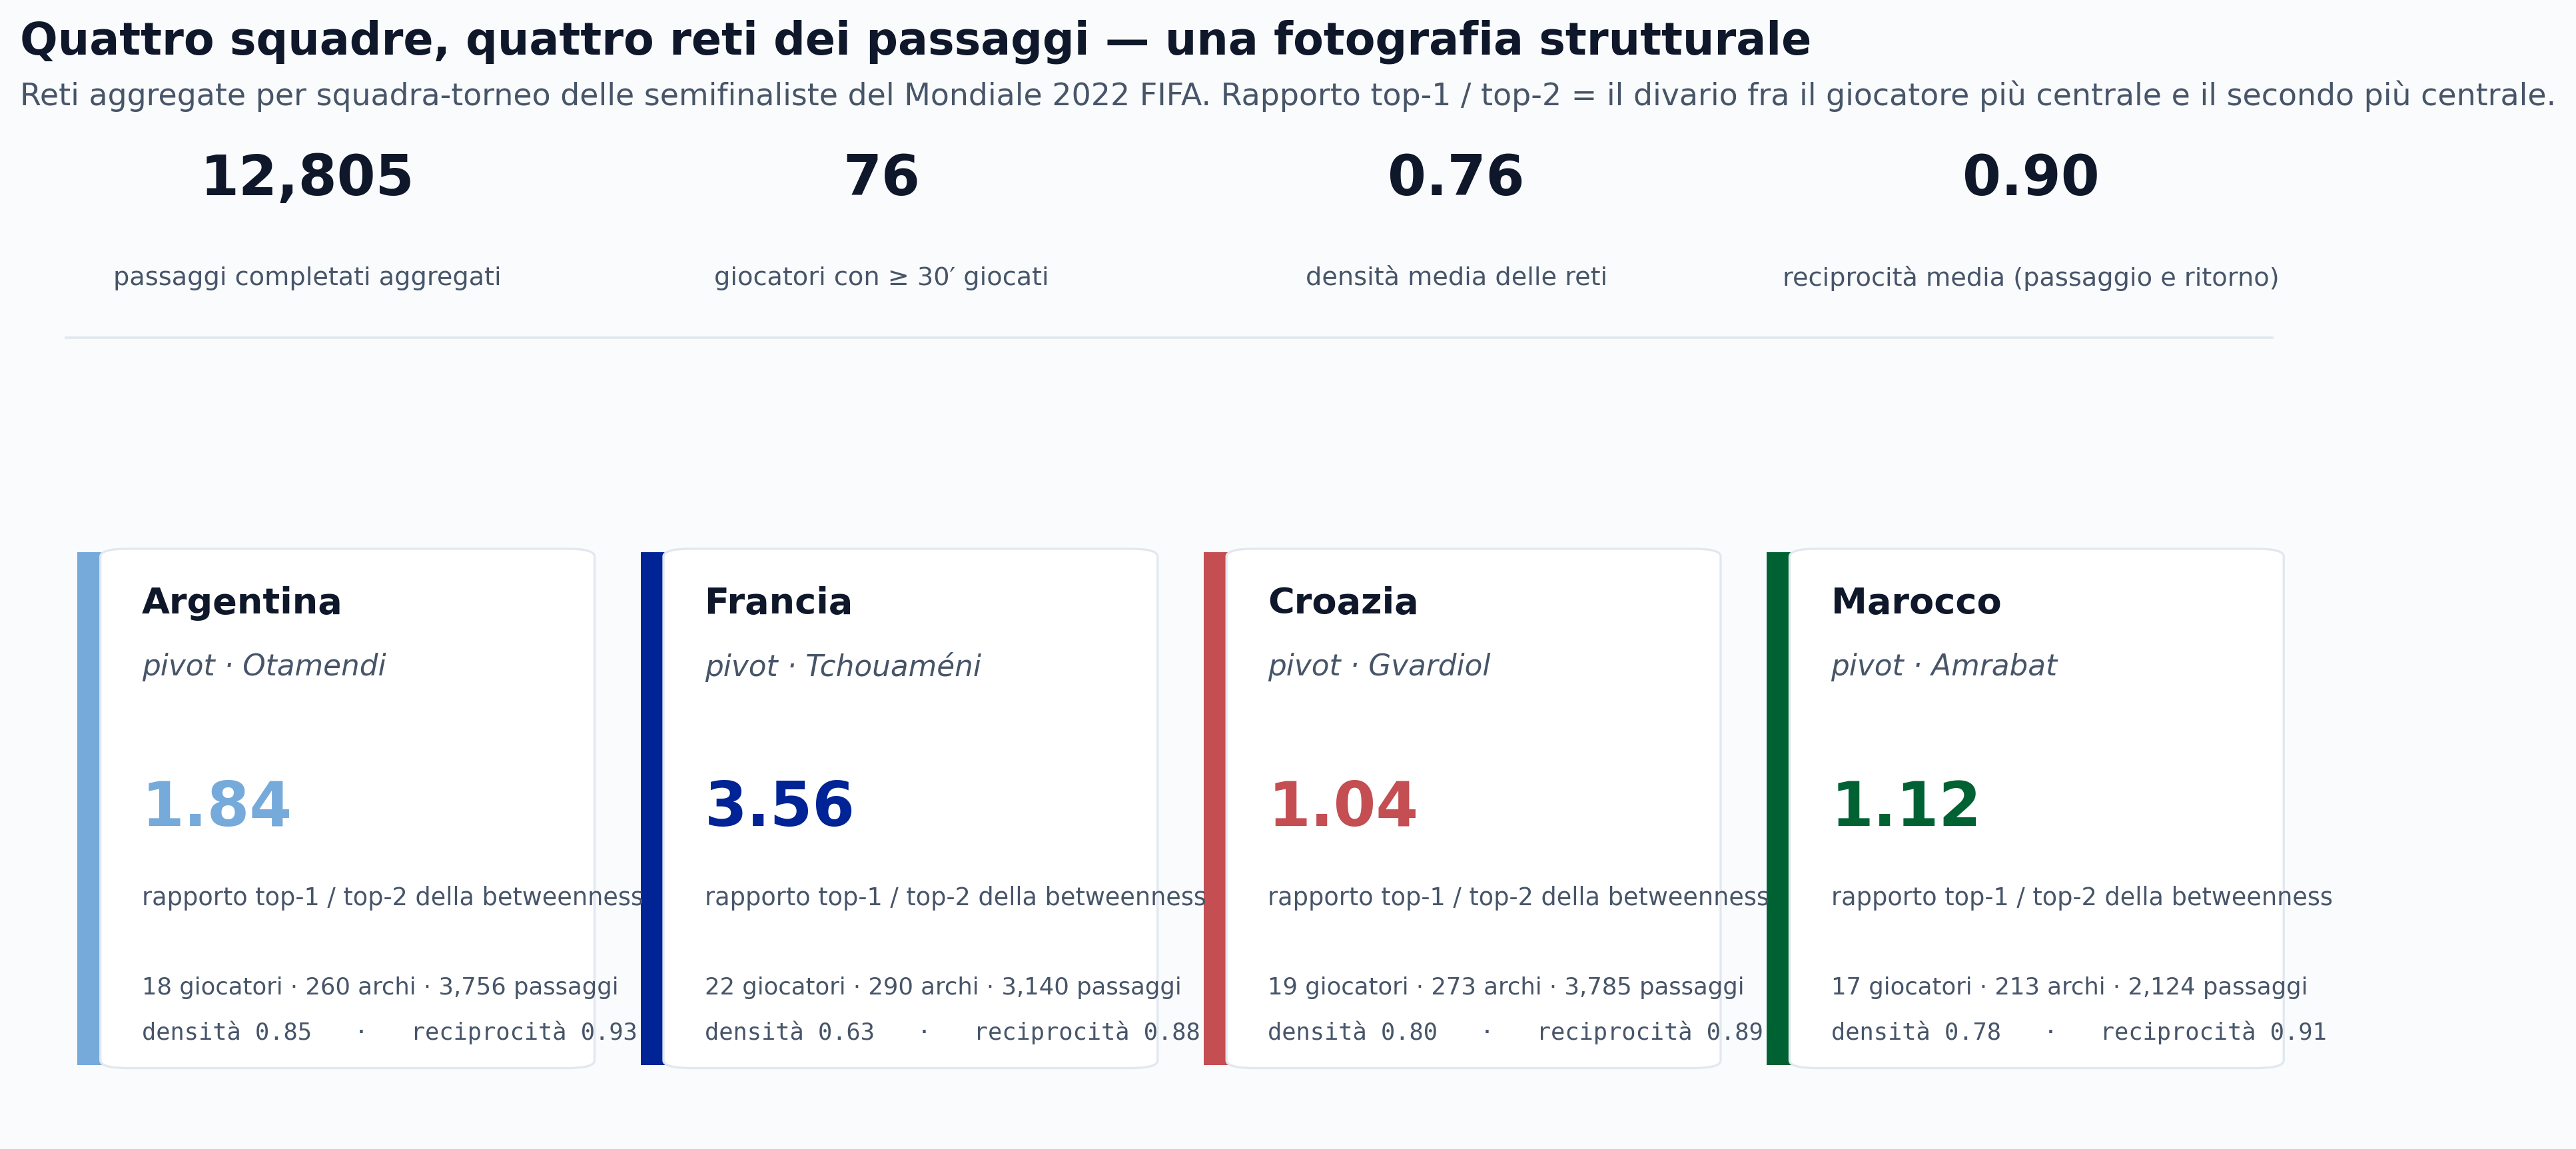

In [3]:
# A visual summary of the four-team setup
fig = plt.figure(figsize=FIG["wide"], facecolor=BG)
gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[1.0, 2.6],
                      left=0.05, right=0.97, top=0.93, bottom=0.06,
                      hspace=0.35)

# --- Title and subtitle directly on the figure
fig.text(0.05, 0.985, "Quattro squadre, quattro reti dei passaggi — una fotografia strutturale",
         ha="left", va="top", fontsize=TEXT["fig_title"],
         fontweight="semibold", color=INK)
fig.text(0.05, 0.935,
         "Reti aggregate per squadra-torneo delle semifinaliste del Mondiale 2022 FIFA. "
         "Rapporto top-1 / top-2 = il divario fra il giocatore più centrale e il secondo più centrale.",
         ha="left", va="top", fontsize=TEXT["fig_subtitle"], color=INK_SOFT)

# --- KPI strip: aggregate totals across the four teams
ax_kpi = fig.add_subplot(gs[0])
total_passes = int(setup_df["total passes"].sum())
total_players = int(setup_df["n"].sum())
mean_density = setup_df["density"].mean()
mean_reciprocity = setup_df["reciprocity"].mean()
add_kpi_strip(ax_kpi, [
    (f"{total_passes:,}",         "passaggi completati aggregati"),
    (f"{total_players}",          "giocatori con ≥ 30′ giocati"),
    (f"{mean_density:.2f}",       "densità media delle reti"),
    (f"{mean_reciprocity:.2f}",   "reciprocità media (passaggio e ritorno)"),
])

# --- Per-team mini-cards
ax_cards = fig.add_subplot(gs[1]); ax_cards.set_axis_off()
ax_cards.set_xlim(0, 1); ax_cards.set_ylim(0, 1)
for i, row in setup_df.iterrows():
    x0 = 0.025 + i * 0.245; x1 = x0 + 0.22
    team = row["team"]; color = TEAM_COLORS[team]
    # Left coloured stripe
    ax_cards.add_patch(Rectangle((x0, 0.10), 0.012, 0.80,
                                 fc=color, ec="none", clip_on=False))
    # Card body
    ax_cards.add_patch(FancyBboxPatch((x0 + 0.015, 0.10), 0.205, 0.80,
        boxstyle="round,pad=0.005,rounding_size=0.012",
        fc="white", ec=MUTED, lw=0.8, clip_on=False))
    # Team name
    team_it = {"Argentina":"Argentina","France":"Francia","Croatia":"Croazia","Morocco":"Marocco"}[team]
    ax_cards.text(x0 + 0.028, 0.82, team_it, ha="left", va="center",
                  fontsize=13, fontweight="semibold", color=INK)
    # Pivot
    ax_cards.text(x0 + 0.028, 0.72, f"pivot · {row['pivot']}", ha="left",
                  va="center", fontsize=10.5, color=INK_SOFT, fontstyle="italic")
    # Top1/top2 ratio - the highlighted number
    ax_cards.text(x0 + 0.028, 0.50, f"{row['top1/top2']:.2f}", ha="left",
                  va="center", fontsize=22, fontweight="semibold", color=color)
    ax_cards.text(x0 + 0.028, 0.36, "rapporto top-1 / top-2 della betweenness",
                  ha="left", va="center", fontsize=8.8, color=INK_SOFT)
    ax_cards.text(x0 + 0.028, 0.22,
                  f"{row['n']} giocatori · {row['edges']} archi · {int(row['total passes']):,} passaggi",
                  ha="left", va="center", fontsize=8.5, color=INK_SOFT)
    ax_cards.text(x0 + 0.028, 0.15,
                  f"densità {row['density']:.2f}   ·   reciprocità {row['reciprocity']:.2f}",
                  ha="left", va="center", fontsize=8.5, color=INK_SOFT,
                  family="monospace")
plt.show()


**Cosa abbiamo imparato.**

- Tutte e quattro le reti sono **dense** (densità 0.63–0.85) e **molto reciproche** (0.88–0.93): in pratica, grafi quasi completi in cui quasi tutti i passaggi sono ricambiati. Questo è interessante di per sé: a livello di torneo aggregato, ogni giocatore di movimento di una squadra finisce per passare la palla a quasi ogni suo compagno almeno una volta. È una caratteristica strutturale di queste reti, e influenzerà le nostre scelte metriche.
- Il **Marocco** è quello fuori dal coro per volume: appena 2 124 passaggi totali contro i 3 100–3 800 delle altre tre. Coerente con uno stile di gioco meno orientato al possesso e più diretto. La **Francia**, all'opposto, ha la rotazione più ampia (22 giocatori sopra i 30′ giocati nel torneo), il che ne abbassa meccanicamente la densità (0.63): più giocatori = più coppie possibili = densità più bassa a parità di passaggi.
- Il **rapporto top-1 / top-2** varia di oltre tre volte fra le quattro squadre: da **1.04** (Croazia — Gvardiol e Modrić praticamente pari merito) a **3.56** (Francia — Tchouaméni nettamente sopra tutti). Questa variabilità è un'ottima notizia: significa che le quattro squadre stanno realmente esplorando diversi stili di gioco, da reti "pluricentriche" a reti "monocentriche", e questo darà abbastanza ampiezza per testare la correlazione fra dominanza e fragilità.
- Il caso della **Croazia** è un piccolo *pareggio strutturale*: nella nostra costruzione Gvardiol viene leggermente prima di Modrić in classifica, ma il rapporto 1.04 dice che sono praticamente indistinguibili. Nel resto del notebook tratteremo Gvardiol come "il" pivot croato per coerenza con la procedura, ma è importante tenere a mente che la stessa analisi con Modrić al posto del difensore darebbe risultati pressoché identici.
- *Ipotesi che verificheremo successivamente:* il rapporto top-1/top-2 dovrebbe predire quanto ogni squadra soffre quando le togliamo il pivot. Squadre con rapporto vicino a 1 dovrebbero essere robuste (hanno un sostituto pronto); squadre con rapporto alto dovrebbero essere fragili (nessuno fa quello che fa il pivot).


---
## 2. Come misurare il danno — perché $S(q)$ qui non basta

La metrica di robustezza standard, vista nella NS07, è

$$ S(q) = \frac{\text{dimensione della LCC dopo aver rimosso una frazione } q}{N}, $$

dove LCC è la *largest connected component* e $N$ è il numero iniziale di nodi. È la metrica con cui Albert, Jeong e Barabási hanno mostrato che le reti scale-free sono robuste agli errori casuali e fragili agli attacchi mirati. Funziona perfettamente sulle reti sparse e di grandi dimensioni per cui è stata pensata, dove togliere abbastanza hub provoca la frammentazione del grafo in tante isole separate.

Sulle nostre reti **non funziona bene**, e il motivo è strutturale. Sono troppo dense (densità 0.63–0.85, con reciprocità sopra 0.88): **togliere un solo nodo non spezza praticamente mai la componente connessa principale**. Lo abbiamo verificato empiricamente su più di 800 rimozioni di prova: in pratica $S(1/N)$ resta sempre vicinissimo a 1, quindi la metrica non discrimina fra rimozioni distruttive e rimozioni innocue. Tutti i giocatori "fanno crollare lo stesso 5–10%" della LCC, semplicemente perché togliere un nodo da una rete quasi completa lascia comunque tutti gli altri collegati fra loro.

Ci servono allora metriche che catturino il **peggioramento qualitativo della rete prima ancora che si rompa**: non *si è spezzata, sì o no?* ma *quanto è diventata meno efficiente?*. Ne usiamo due, complementari fra loro:

- **Lunghezza media dei cammini** sulla LCC, usando `1/peso` come distanza, così che passaggi frequenti corrispondano a percorsi brevi. È sensibile al *picco peggiore*: se anche una sola coppia di giocatori ora deve fare un giro lungo per scambiarsi la palla, l'indice sale.
- **Efficienza globale** $E = \frac{1}{n(n-1)}\sum_{i \neq j} \frac{1}{d_{ij}}$ — la media degli inversi delle distanze fra tutte le coppie raggiungibili (Latora & Marchiori 2001). Per costruzione, dà più peso alle coppie *vicine* e meno alle coppie *lontane*, quindi cattura piuttosto il *tono medio* della rete che il picco. Più è bassa, più lentamente la palla circola complessivamente.

Le due metriche guardano lo stesso fenomeno da due angoli diversi: la lunghezza media è dominata dalle coppie che stanno peggio, l'efficienza dalle coppie che stanno meglio. In una rete *molto* danneggiata si muovono entrambe nello stesso verso; in una rete *localmente* danneggiata si muovono di importi diversi, e il rapporto fra i due cambiamenti è informativo. Useremo proprio questa complementarità per leggere il caso di ogni singola squadra.

In entrambi i casi riporteremo il **danno relativo** rispetto al baseline, scegliendo il segno in modo che *un valore positivo significhi sempre "peggio di prima"*: per la lunghezza media usiamo $(\text{post} - \text{pre})/\text{pre}$, perché cammini più lunghi sono peggio; per l'efficienza usiamo $(\text{pre} - \text{post})/\text{pre}$, perché efficienza più bassa è peggio.


In [4]:
baseline_rows = []
for team in TEAMS:
    G = graphs[team]
    baseline_rows.append({
        "team":             team,
        "avg path length":  avg_path_length(G),
        "efficiency":       efficiency(G),
    })
baseline_df = pd.DataFrame(baseline_rows).set_index("team")
print(baseline_df.round(3).to_string())


           avg path length  efficiency
team                                  
Argentina            0.078      19.073
France               0.171      11.010
Croatia              0.108      16.671
Morocco              0.151      10.987


**Cosa abbiamo imparato.**

- L'**Argentina** ha i cammini più corti (0.078) e l'efficienza più alta (19.07): una rete di possesso fitta e ben collegata, in cui la palla impiega in media meno passaggi (pesati) per andare da chiunque a chiunque. Coerente con l'alto volume di passaggi e con un flusso che, pur avendo in Otamendi uno snodo netto, resta ben distribuito.
- La **Croazia** è la seconda su entrambe le metriche (cammini 0.108, efficienza 16.67): rete efficiente quasi quanto l'Argentina, anche se senza un singolo snodo che accorci i cammini al massimo — un'anticipazione del fatto che la Croazia non ha un *imbuto* strutturale unico.
- La **Francia** ha i cammini **più lunghi** delle quattro (0.171), pur con un buon volume di passaggi: la rotazione ampia (22 giocatori) e la densità più bassa (0.63) allungano meccanicamente i cammini pesati ottimali — più giocatori e meno densità significano che, in media, la palla deve fare qualche passaggio in più per collegare due compagni qualsiasi.
- Il **Marocco** ha l'efficienza **più bassa** (10.99) e i secondi cammini più lunghi (0.151): coerente con uno stile meno basato sul possesso (appena 2 124 passaggi, meno scambi, più forzature nei cammini ottimali).
- Le due metriche **non ordinano le squadre allo stesso modo**: per lunghezza dei cammini l'ordine è Argentina < Croazia < Marocco < Francia, per efficienza è Argentina > Croazia > Francia > Marocco. La Francia ne è il caso emblematico — i cammini più lunghi ma efficienza sopra il Marocco — perché le sue coppie *vicine* restano ben collegate (tono medio alto) mentre qualche coppia *lontana* paga un percorso lungo (picco peggiore). È esattamente la complementarità descritta sopra: la lunghezza media è dominata dalle coppie peggiori, l'efficienza dal grosso delle coppie vicine.
- Questi quattro valori (per due metriche) sono il *baseline* con cui confronteremo il danno della rimozione di un giocatore. Tutto il resto del notebook è la storia di *quanto questi numeri peggiorano*.


---
## 3. Togliere un giocatore — pivot vs giocatore a caso

Per ogni squadra ripetiamo l'esperimento di attacco mirato della Lezione 7, ma in versione mini e contro un modello nullo opportuno. La logica è la stessa di un *permutation test*:

| | Cosa togliamo | Quante volte |
|---|---|---|
| **Mirato** | il giocatore top-1 per weighted betweenness (il pivot) | 1 |
| **Casuale** | un giocatore di movimento a caso (escluso il portiere e il pivot) | $N = 200$ |

Il *modello nullo* qui è "se togliessimo un giocatore qualunque non-pivot, quanto danno ci aspetteremmo?". Le 200 rimozioni casuali ricostruiscono la distribuzione di questo "danno tipico". Confrontando il singolo danno mirato con questa distribuzione, possiamo dire se togliere il pivot è effettivamente più dannoso o se rientra in ciò che ci si aspetterebbe dal caso.

Escludiamo il portiere dalle rimozioni casuali per due motivi. Primo, il portiere ha una posizione strutturale molto particolare (è praticamente uno *spoke* unidirezionale: riceve indietro e rilancia in avanti), e la sua rimozione tende a essere distruttiva per ragioni che non hanno nulla a che fare con la centralità nel senso che ci interessa qui. Secondo, nessun allenatore *toglie* il portiere in senso tattico, mentre toglie regolarmente difensori e centrocampisti, quindi il pool casuale rispecchia anche un'idea di plausibilità calcistica.

Per ogni combinazione squadra × metrica, trasformiamo il danno mirato in **z-score** rispetto alla distribuzione delle 200 rimozioni casuali:

$$ z = \frac{\text{danno mirato} - \text{media dei danni casuali}}{\text{deviazione standard dei danni casuali}}. $$

Un $z$ pari a +1 significa "il danno mirato è una deviazione standard sopra la media dei danni casuali" (poco eccezionale); un $z$ pari a +4 significa "il danno mirato è quattro deviazioni standard sopra la media" (eccezionale: meno dello 0.01% delle rimozioni casuali raggiungerebbe questo livello sotto ipotesi gaussiana). Riportiamo anche il **p-value a una coda**, cioè la frazione di rimozioni casuali che raggiungono o superano il danno fatto dal togliere il pivot: è la versione *non parametrica* dello z-score, non assume distribuzione gaussiana e per piccoli campioni è leggermente più conservativa. Attenzione: gli asterischi di significatività nella figura si riferiscono a questo p non parametrico, non allo z-score. Quando la distribuzione nulla è multimodale (come per la Croazia), un p molto basso può convivere con uno z modesto — segnalano cose diverse, e per giudicare la *robustezza* relativa fra squadre guardiamo lo z-score medio, non gli asterischi.


In [5]:
metrics = {"avg_path_length": avg_path_length, "efficiency": efficiency}

rows = []
for team in TEAMS:
    G = graphs[team]
    btw = weighted_betweenness(G); pivot = max(btw, key=btw.get)
    pre = {m: f(G) for m, f in metrics.items()}

    # Targeted
    Gt = G.copy(); Gt.remove_node(pivot)
    post = {m: f(Gt) for m, f in metrics.items()}
    for m in metrics:
        rows.append({"team": team, "mode": "targeted", "realisation": 0,
                     "metric": m,
                     "damage": relative_damage(pre[m], post[m], m)})

    # Random null
    rng = np.random.default_rng(RANDOM_SEED)
    outfield = [n for n in G.nodes() if G.nodes[n].get("line") != "GK" and n != pivot]
    for r in range(N_RANDOM):
        n_remove = rng.choice(outfield)
        Gr = G.copy(); Gr.remove_node(n_remove)
        post = {m: f(Gr) for m, f in metrics.items()}
        for m in metrics:
            rows.append({"team": team, "mode": "random", "realisation": r,
                         "metric": m,
                         "damage": relative_damage(pre[m], post[m], m)})

df = pd.DataFrame(rows)

# Summary table.
summary = []
for team in TEAMS:
    for m in metrics:
        sub = df[(df.team == team) & (df.metric == m)]
        t = sub[sub["mode"] == "targeted"]["damage"].iloc[0]
        rvs = sub[sub["mode"] == "random"]["damage"].dropna().values
        rmean, rstd = rvs.mean(), rvs.std(ddof=1)
        z = (t - rmean) / rstd if rstd > 0 else float("nan")
        p = float(np.mean(rvs >= t))
        summary.append({"team": team, "metric": m,
                        "targeted": round(t, 4),
                        "random mean": round(rmean, 4),
                        "random std":  round(rstd, 4),
                        "z": round(z, 2), "p": round(p, 3)})
summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))


     team          metric  targeted  random mean  random std    z    p
Argentina avg_path_length    0.3030       0.0155      0.0616 4.66 0.00
Argentina      efficiency    0.2127       0.0059      0.0589 3.51 0.00
   France avg_path_length    0.2425       0.0097      0.0489 4.76 0.00
   France      efficiency    0.1689       0.0028      0.0535 3.11 0.00
  Croatia avg_path_length    0.1024       0.0116      0.0636 1.43 0.05
  Croatia      efficiency    0.1250      -0.0016      0.0724 1.75 0.00
  Morocco avg_path_length    0.1745       0.0315      0.0726 1.97 0.09
  Morocco      efficiency    0.1280       0.0102      0.0710 1.66 0.09


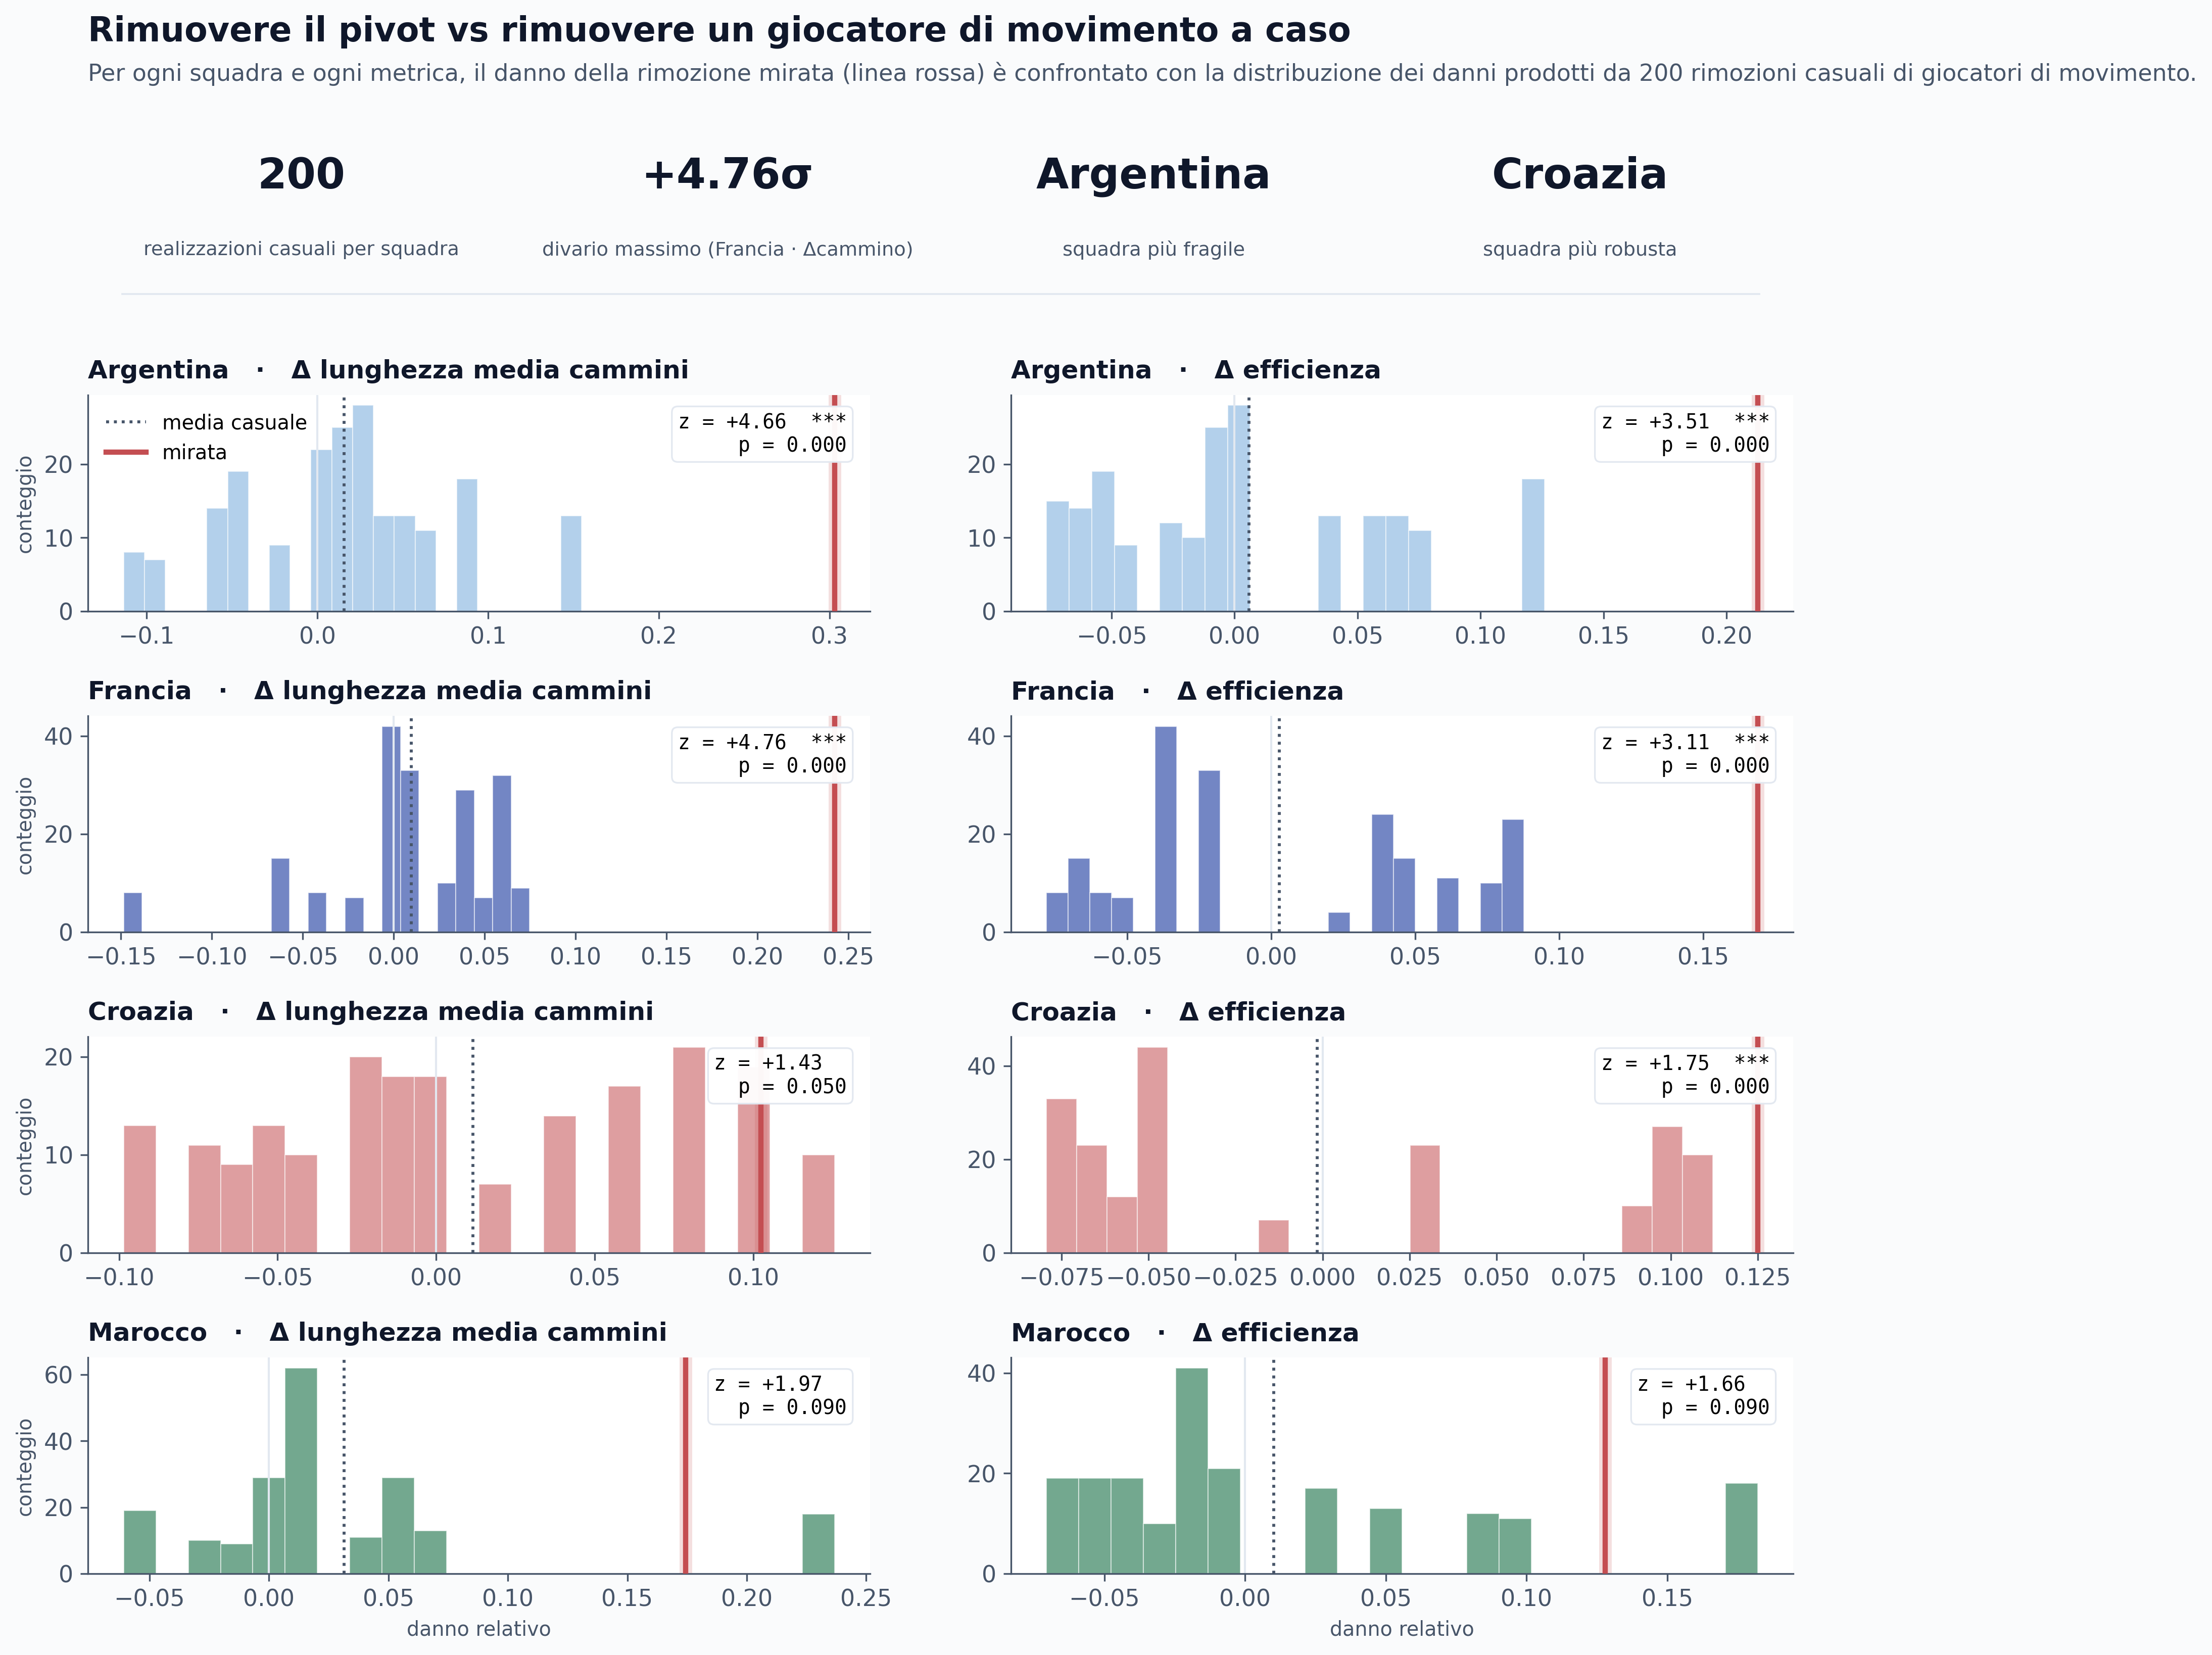

In [6]:
# Hero figure for §3: KPI band + 4×2 grid of histograms with targeted overlay.
_team_it_map = {"Argentina":"Argentina","France":"Francia","Croatia":"Croazia","Morocco":"Marocco"}
fig = plt.figure(figsize=FIG["grid"], facecolor=BG)
gs = fig.add_gridspec(nrows=5, ncols=2, height_ratios=[0.85, 1, 1, 1, 1],
                      left=0.07, right=0.97, top=0.93, bottom=0.05,
                      hspace=0.50, wspace=0.18)

fig.text(0.07, 0.985, "Rimuovere il pivot vs rimuovere un giocatore di movimento a caso",
         ha="left", va="top", fontsize=TEXT["fig_title"], fontweight="semibold",
         color=INK)
fig.text(0.07, 0.957,
         "Per ogni squadra e ogni metrica, il danno della rimozione mirata (linea rossa) è confrontato "
         "con la distribuzione dei danni prodotti da 200 rimozioni casuali di giocatori di movimento.",
         ha="left", va="top", fontsize=TEXT["fig_subtitle"], color=INK_SOFT)

# KPI strip across the top
ax_kpi = fig.add_subplot(gs[0, :])
ranked = summary_df.groupby("team")["z"].mean().sort_values(ascending=False)
most_fragile, least_fragile = ranked.index[0], ranked.index[-1]
max_z = summary_df["z"].max()
mean_z = summary_df["z"].mean()
add_kpi_strip(ax_kpi, [
    (f"{N_RANDOM}",                     "realizzazioni casuali per squadra"),
    (f"{max_z:+.2f}σ",                  f"divario massimo (Francia · Δcammino)"),
    (_team_it_map.get(most_fragile, most_fragile),    "squadra più fragile"),
    (_team_it_map.get(least_fragile, least_fragile),  "squadra più robusta"),
])

# The 4×2 grid
for i, team in enumerate(TEAMS):
    for j, metric in enumerate(["avg_path_length", "efficiency"]):
        ax = fig.add_subplot(gs[i + 1, j])
        sub = df[(df.team == team) & (df.metric == metric)]
        rand_vals = sub[sub["mode"] == "random"]["damage"].dropna().values
        targ_val  = sub[sub["mode"] == "targeted"]["damage"].iloc[0]
        # Histogram of random null
        ax.hist(rand_vals, bins=22, color=TEAM_COLORS[team], alpha=0.55,
                edgecolor="white", linewidth=0.5)
        ax.axvline(0, color=MUTED, lw=1.0, zorder=1)
        # Random mean
        ax.axvline(rand_vals.mean(), color=INK_SOFT, linestyle=":",
                   linewidth=1.4, label="media casuale")
        # Targeted: three-pass glow effect for emphasis
        ax.axvline(targ_val, color=HIGHLIGHT, linewidth=6, alpha=0.18, zorder=2)
        ax.axvline(targ_val, color=HIGHLIGHT, linewidth=2.5, zorder=3,
                   label="mirata")
        # z and p chip in the corner
        z = (targ_val - rand_vals.mean()) / rand_vals.std(ddof=1)
        p_val = float(np.mean(rand_vals >= targ_val))
        sig = "***" if p_val < 0.001 else ("**" if p_val < 0.01 else ("*" if p_val < 0.05 else ""))
        ax.text(0.97, 0.92, f"z = {z:+.2f}  {sig}\np = {p_val:.3f}",
                transform=ax.transAxes, ha="right", va="top",
                fontsize=TEXT["annotation"], family="monospace",
                bbox=dict(boxstyle="round,pad=0.30", fc="white", ec=MUTED,
                          lw=0.8, alpha=0.96))
        # Title (panel-style)
        nice_metric = {"avg_path_length": "Δ lunghezza media cammini",
                       "efficiency": "Δ efficienza"}[metric]
        team_it = {"Argentina":"Argentina","France":"Francia","Croatia":"Croazia","Morocco":"Marocco"}[team]
        style_panel(ax, title=f"{team_it}   ·   {nice_metric}", subtitle=None)
        ax.set_xlabel("danno relativo" if i == 3 else "",
                      fontsize=TEXT["annotation"], color=INK_SOFT)
        ax.set_ylabel("conteggio" if j == 0 else "",
                      fontsize=TEXT["annotation"], color=INK_SOFT)
        if i == 0 and j == 0:
            ax.legend(loc="upper left", frameon=False,
                      fontsize=TEXT["annotation"])

plt.show()


**Cosa abbiamo imparato.**

- Per tutte e quattro le squadre, **togliere il pivot fa più danni della media delle rimozioni casuali**, su entrambe le metriche. Il giocatore top-1 in betweenness sta davvero facendo qualcosa che gli altri non fanno. Questo conferma la nostra ipotesi base: la weighted betweenness, malgrado sia definita su un grafo astratto, identifica giocatori che hanno un ruolo strutturalmente distinto nella rete dei passaggi.
- L'**Argentina** è la squadra che soffre di più: $z = +4.66$ sulla Δlunghezza media dei cammini e $z = +3.51$ sulla Δefficienza. Otamendi è strutturalmente insostituibile — togliere lui produce un danno quattro volte la deviazione standard delle rimozioni casuali. Più del 99.5% delle 200 rimozioni di controllo provocano meno danno della rimozione di Otamendi su entrambe le metriche.
- La **Francia** è subito dietro su entrambe le metriche ($z = +4.76$ su Δcammino; $z = +3.11$ su Δefficienza). Togliere Tchouaméni è praticamente impossibile da replicare per caso. Sul Δcammino la Francia è addirittura *leggermente più estrema* dell'Argentina, ma sulla Δefficienza l'Argentina la supera — torneremo su questa differenza nel paragrafo sotto.
- La **Croazia** è la più robusta delle quattro: $z = +1.43$ su Δcammino e $z = +1.75$ su Δefficienza. Togliere Gvardiol (o, in modo equivalente, Modrić — sono praticamente pari merito) sembra una perdita seria ma non catastrofica, ben dentro l'envelope delle rimozioni casuali. La squadra ha della ridondanza, coerente con un centrocampo di tre pivot quasi intercambiabili (Modrić, Brozović, Kovačić).
- Il **Marocco** sta in mezzo ($z \approx +1.7$ su entrambe le metriche): un pivot identificabile ma non così dominante come quelli di Argentina e Francia. La cosa interessante è che, dei quattro, è la squadra dove pivot e secondo (Amrabat e Hakimi) sono per ruolo i più diversi fra loro — un centrocampista difensivo e un terzino offensivo — eppure la dominanza strutturale resta modesta.
- Una piccola sottigliezza che vale la pena notare: Argentina e Francia hanno *Δ-cammino* praticamente identica (z 4.66 vs 4.76), ma la Argentina ha *Δ-efficienza* sensibilmente più alta (z 3.51 vs 3.11). In termini di rete, significa che togliere Otamendi danneggia non solo le coppie più lontane (cammini) ma in modo significativo anche quelle vicine (efficienza), mentre togliere Tchouaméni danneggia soprattutto le coppie più lontane. Otamendi è quindi un pivot un po' più *pervasivo* di Tchouaméni: il suo ruolo si fa sentire ovunque, non solo sui collegamenti più lunghi. Questo è anche un'anteprima di un risultato che troveremo in seguito: l'Argentina sarà l'unico outlier della retta di regressione, e il motivo sarà che il rapporto top-1/top-2 di 1.84 sottostima quanto Otamendi è strutturalmente centrale.


---
## 4. Togliere più giocatori — uno, due, tre

Togliere un solo giocatore ci dice quanto la squadra dipende da quel singolo nome. Ma una squadra può essere *fragile su un nome solo* (toglielo e crolla, ma il secondo è meno critico) oppure *fragile in profondità* (i primi tre sono tutti hub). L'esperimento classico di Albert, Jeong e Barabási (2000) ci dà la chiave per distinguere i due casi: a ogni passo **ricalcoliamo la betweenness sul grafo rimasto** e togliamo il nuovo top-1. La curva del danno cumulativo si chiama, nella letteratura, *attack curve*, e la sua forma rivela quanti hub effettivi ha la rete.

**Una nota sul termine «hub».** Nell'articolo originale di Albert, Jeong e Barabási un *hub* è un nodo di **grado** alto (tante connessioni), e l'attacco classico rimuove proprio i nodi di grado più alto. Qui invece rimuoviamo i nodi di **betweenness** più alta, in quanto le nostre reti sono così dense (densità 0.63–0.85, reciprocità sopra 0.88) che il grado è quasi saturo per tutti e non discrimina più chi conta da chi no. È la betweenness pesata a separare i giocatori, perché identifica chi fa da *snodo del flusso* (il regista) e non chi ha semplicemente più passaggi. Quando in questa sezione diciamo «hub» intendiamo quindi un **hub di flusso**, non di grado: un nodo che concentra una quota molto elevata di cammini ottimali, così come l'hub di grado concentra le connessioni in una rete scale-free. Il punto interessante è proprio che il pattern di Albert-Jeong-Barabási — robusta agli errori casuali, fragile agli attacchi mirati — non dipende dal *tipo* di risorsa concentrata (il grado lì, il flusso qui) ma dalla sua **eterogeneità**.

È importante che la betweenness venga *ricalcolata a ogni passo* e non calcolata una sola volta all'inizio. È un errore comune nella letteratura applicativa: se uno calcola i top-3 iniziali e li toglie tutti insieme, sta misurando una cosa diversa — sta misurando quanto importano i tre nodi che *erano* i top-3 prima di rimuovere chiunque. Ricalcolando, invece, simuliamo fedelmente lo scenario "togliamo sempre il nodo più critico *al momento corrente*", che è la versione coerente con l'idea di *attacco* di Albert-Jeong-Barabási.

Ci fermiamo dopo tre rimozioni per due motivi pratici. Primo, ai passi successivi la lunghezza media dei cammini diventa rumorosa: rimuovere il quarto o quinto nodo da una rete che ne ha già persi tre porta la rete vicina alla soglia di frammentazione e i numeri diventano dominati dal *quale* sottografo è rimasto, non da *quanto* l'abbiamo danneggiato. Secondo, dal punto di vista calcistico, "togliere i primi tre della betweenness" corrisponde grossomodo a *un trio di infortuni nel nucleo strategico della squadra*, scenario realistico per un mondiale; "togliere i primi sei" è uno scenario apocalittico che esce dall'analisi sensata.

Affianchiamo a ogni curva mirata la corrispondente **curva di rimozione casuale** — tre nodi tolti a caso uno dopo l'altro (sempre esclusi pivot e portiere), mediata sulle 200 realizzazioni — come riferimento visivo immediato (linea tratteggiata). Non rifacciamo l'analisi con z-score della §3: qui il punto è la *forma* qualitativa della curva, non la significatività della differenza.


In [7]:
# ---- Attacco mirato progressivo: ricalcola la betweenness e toglie il nuovo top-1 a ogni passo.
prog_rows = []
for team in TEAMS:
    G_curr = graphs[team].copy()
    baseline = {m: f(G_curr) for m, f in metrics.items()}
    removed = []
    for step in range(4):
        post = {m: f(G_curr) for m, f in metrics.items()}
        prog_rows.append({
            "team":   team,
            "step":   step,
            "removed so far": ", ".join(short(n) for n in removed) or "\u2014",
            "\u0394 avg path length": relative_damage(baseline["avg_path_length"],
                                                  post["avg_path_length"],
                                                  "avg_path_length"),
            "\u0394 efficiency":       relative_damage(baseline["efficiency"],
                                                  post["efficiency"],
                                                  "efficiency"),
        })
        if step < 3:
            btw = weighted_betweenness(G_curr)
            nxt = max(btw, key=btw.get)
            removed.append(nxt)
            G_curr.remove_node(nxt)

prog_df = pd.DataFrame(prog_rows)

# ---- Riferimento casuale: rimozione cumulativa di 3 nodi di movimento (esclusi pivot e
#      portiere)
rand_prog_rows = []
for team in TEAMS:
    G0 = graphs[team]
    baseline = {m: f(G0) for m, f in metrics.items()}
    btw0 = weighted_betweenness(G0); pivot0 = max(btw0, key=btw0.get)
    outfield = [n for n in G0.nodes()
                if G0.nodes[n].get("line") != "GK" and n != pivot0]
    rng = np.random.default_rng(RANDOM_SEED)
    acc = {step: {m: [] for m in metrics} for step in (1, 2, 3)}
    for _ in range(N_RANDOM):
        chosen = rng.choice(outfield, size=3, replace=False)
        G_curr = G0.copy()
        for step, node in enumerate(chosen, start=1):
            G_curr.remove_node(node)
            for m, f in metrics.items():
                acc[step][m].append(relative_damage(baseline[m], f(G_curr), m))
    for step in (0, 1, 2, 3):
        if step == 0:
            apl_v = eff_v = 0.0
        else:
            apl_v = float(np.nanmean(acc[step]["avg_path_length"]))
            eff_v = float(np.nanmean(acc[step]["efficiency"]))
        rand_prog_rows.append({"team": team, "step": step,
                               "\u0394 avg path length": apl_v,
                               "\u0394 efficiency": eff_v})
rand_prog_df = pd.DataFrame(rand_prog_rows)

print(prog_df.round(3).to_string(index=False))


     team  step                removed so far  Δ avg path length  Δ efficiency
Argentina     0                             —              0.000         0.000
Argentina     1                      Otamendi              0.303         0.213
Argentina     2             Otamendi, De Paul              0.452         0.351
Argentina     3  Otamendi, De Paul, Fernandez              0.693         0.456
   France     0                             —              0.000         0.000
   France     1                    Tchouaméni              0.243         0.169
   France     2            Tchouaméni, Varane              0.465         0.279
   France     3 Tchouaméni, Varane, Griezmann              0.569         0.338
  Croatia     0                             —              0.000         0.000
  Croatia     1                      Gvardiol              0.102         0.125
  Croatia     2              Gvardiol, Modrić              0.264         0.268
  Croatia     3     Gvardiol, Modrić, Kovačić       

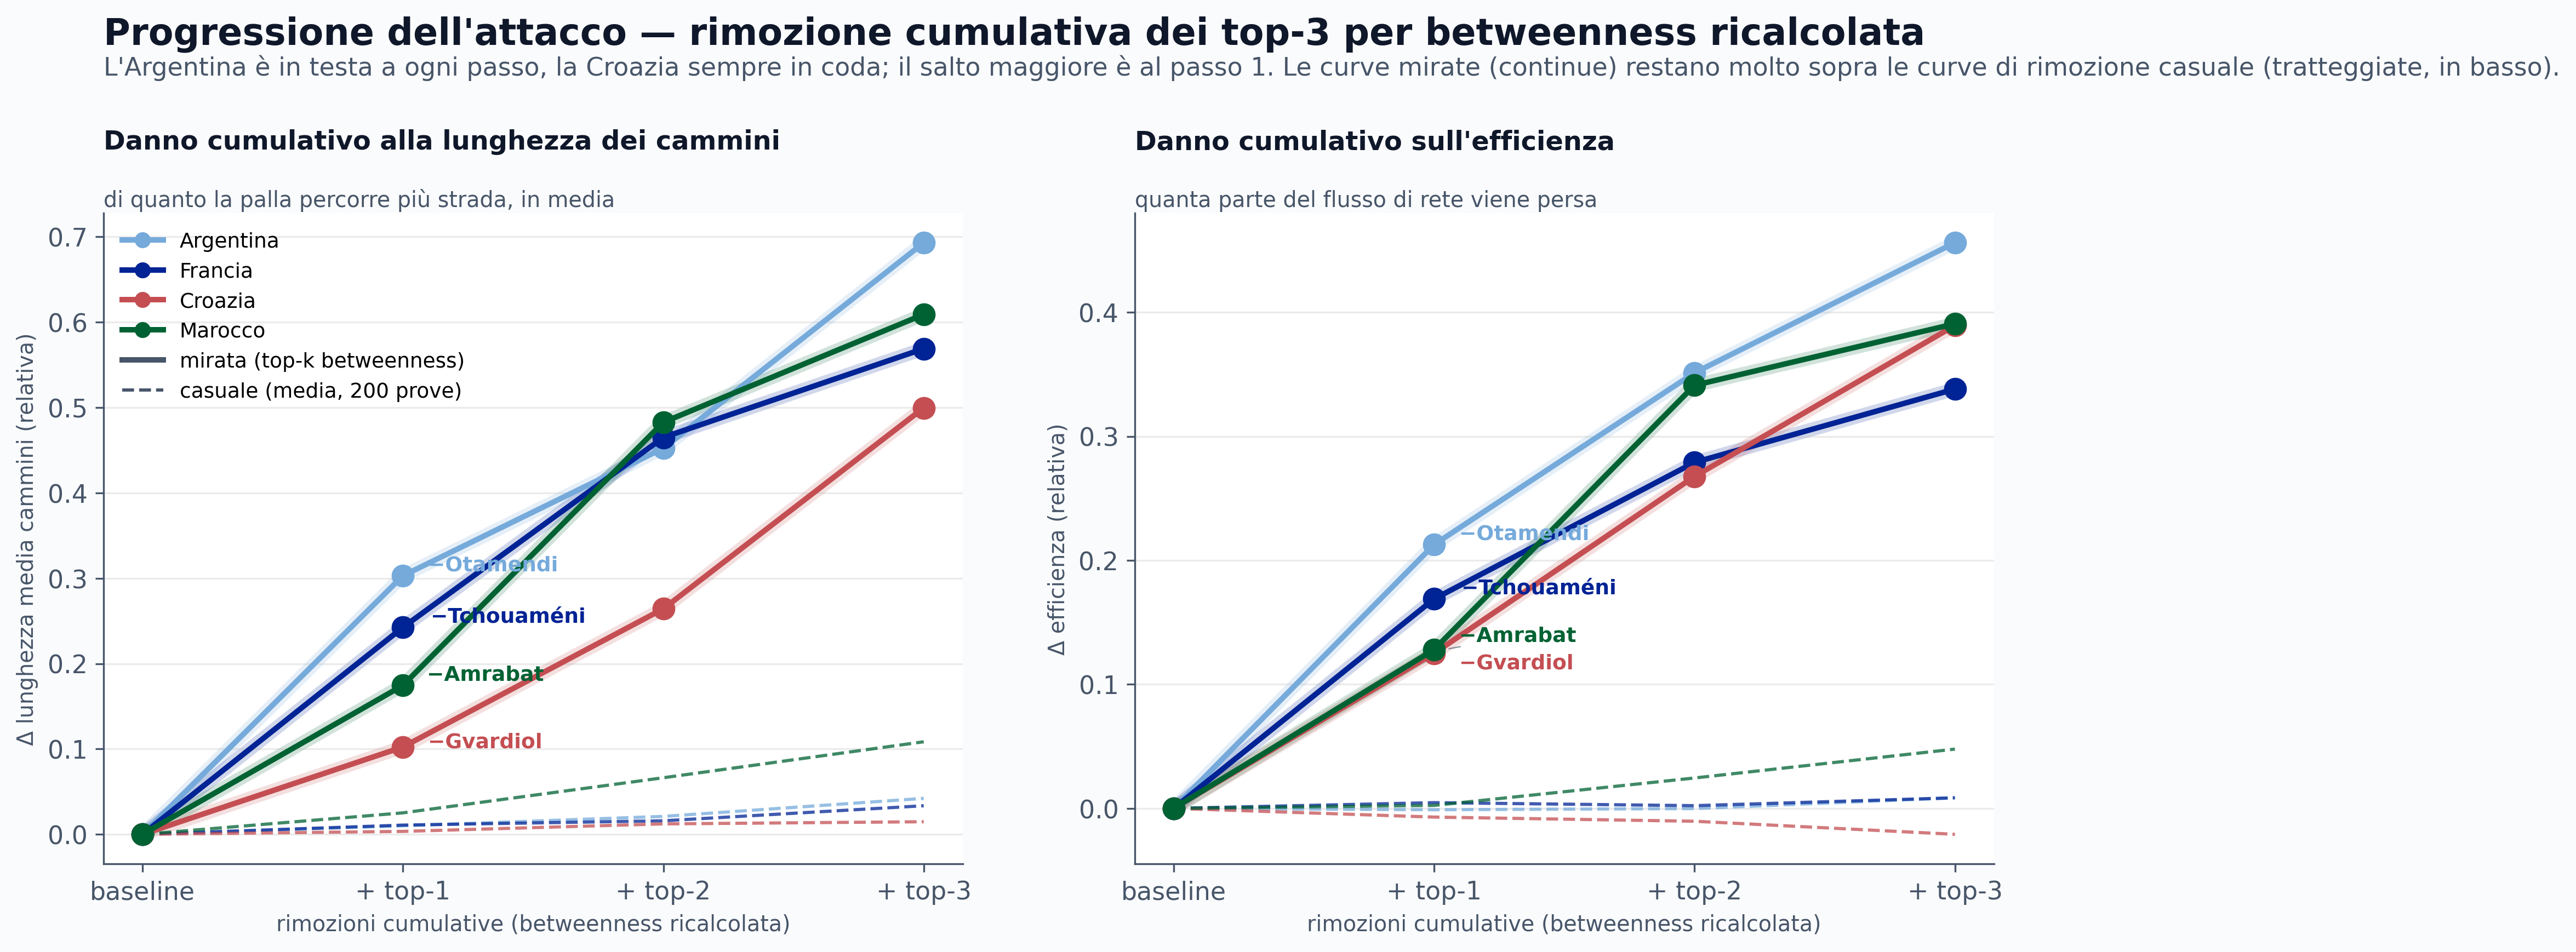

In [8]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from adjustText import adjust_text

_team_it = {"Argentina": "Argentina", "France": "Francia",
            "Croatia": "Croazia", "Morocco": "Marocco"}

fig, axes = plt.subplots(1, 2, figsize=FIG["wide"], facecolor=BG)

for ax, metric, ylabel, panel_title, panel_subtitle in zip(
    axes,
    ["\u0394 avg path length", "\u0394 efficiency"],
    ["\u0394 lunghezza media cammini (relativa)", "\u0394 efficienza (relativa)"],
    ["Danno cumulativo alla lunghezza dei cammini",
     "Danno cumulativo sull'efficienza"],
    ["di quanto la palla percorre pi\u00f9 strada, in media",
     "quanta parte del flusso di rete viene persa"],
):
    texts = []
    for team in TEAMS:
        sub = prog_df[prog_df.team == team]
        rnd = rand_prog_df[rand_prog_df.team == team]
        color = TEAM_COLORS[team]

        # Curva mirata: alone + linea continua con marcatori
        ax.plot(sub.step, sub[metric], color=color, lw=6, alpha=0.18, zorder=1)
        ax.plot(sub.step, sub[metric], marker="o", markersize=9, linewidth=2.4,
                color=color, label=_team_it[team], zorder=3)

        # Curva casuale: linea sottile tratteggiata, stesso colore, senza marcatori
        ax.plot(rnd.step, rnd[metric], color=color, lw=1.4, ls="--",
                alpha=0.75, zorder=2)

        # Etichetta del pivot al passo 1, sulla curva mirata
        step1 = sub[sub.step == 1].iloc[0]
        t = ax.text(1.04, step1[metric], f"\u2212{step1['removed so far']}",
                    fontsize=TEXT["annotation"] - 0.5, color=color,
                    fontweight="semibold", zorder=5)
        texts.append(t)

    adjust_text(texts, ax=ax, only_move={"text": "y"},
                arrowprops=dict(arrowstyle="-", color=INK_SOFT, lw=0.6, alpha=0.6))

    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(["baseline", "+ top-1", "+ top-2", "+ top-3"])
    ax.set_ylabel(ylabel, fontsize=TEXT["annotation"], color=INK_SOFT)
    ax.set_xlabel("rimozioni cumulative (betweenness ricalcolata)",
                  fontsize=TEXT["annotation"], color=INK_SOFT)
    ax.grid(True, alpha=0.25, axis="y")
    ax.set_title(panel_title, fontsize=TEXT["annotation"] + 2, color=INK,
                 pad=28, loc="left", fontweight="semibold")
    ax.text(0, 1.01, panel_subtitle, transform=ax.transAxes,
            fontsize=TEXT["annotation"], color=INK_SOFT, ha="left")

# Legenda: squadre + spiegazione continua/tratteggiata
team_handles = [Line2D([0], [0], color=TEAM_COLORS[t], lw=2.4, marker="o",
                       label=_team_it[t]) for t in TEAMS]
style_handles = [
    Line2D([0], [0], color=INK_SOFT, lw=2.4, label="mirata (top-k betweenness)"),
    Line2D([0], [0], color=INK_SOFT, lw=1.4, ls="--",
           label="casuale (media, 200 prove)"),
]
axes[0].legend(handles=team_handles + style_handles, loc="upper left",
               frameon=False, fontsize=TEXT["annotation"] - 0.5, ncol=1)

fig.suptitle("Progressione dell'attacco \u2014 rimozione cumulativa dei top-3 per betweenness ricalcolata",
             fontsize=TEXT["fig_title"], fontweight="bold", color=INK,
             x=0.06, ha="left", y=0.98)
fig.text(0.06, 0.92,
         "L'Argentina \u00e8 in testa a ogni passo, la Croazia sempre in coda; il salto maggiore \u00e8 al passo 1. "
         "Le curve mirate (continue) restano molto sopra le curve di rimozione casuale (tratteggiate, in basso).",
         fontsize=TEXT["fig_subtitle"], color=INK_SOFT, ha="left")

plt.subplots_adjust(left=0.06, right=0.98, top=0.78, bottom=0.12, wspace=0.20)
plt.show()


**Cosa abbiamo imparato.**

- Le curve di danno **crescono sempre**, e il salto più grosso è quasi sempre fra il baseline e il passo 1 (l'effetto del pivot). Il comportamento ai passi successivi però varia per squadra: la **Francia** rallenta dopo Tchouaméni (segno che, tolto lui, il centrocampo non offre altri snodi forti), mentre **Argentina** e **Croazia** continuano a peggiorare in modo marcato anche ai passi 2 e 3, perché hanno più hub in sequenza da perdere.
- L'**Argentina** ha il danno più grande **a ogni passo**: dal passo 1 (Otamendi: $\Delta$cammino = 0.30, $\Delta$efficienza = 0.21) fino al passo 3 (Otamendi → De Paul → Fernández), dove la $\Delta$cammino arriva a 0.69, la più alta delle quattro. Coerente con la §3: ha tre giocatori molto centrali in fila e toglierli tutti appiattisce la rete.
- La **Francia** segue da vicino: Tchouaméni → Varane → Griezmann porta la $\Delta$cammino a 0.57. Da notare che il *secondo* nodo più critico è un difensore (Varane): una volta tolto Tchouaméni, il centrocampo non offre più snodi forti e la palla è costretta a girare attraverso la difesa.
- La **Croazia** è il caso opposto: danno minimo al passo 1 e curva più contenuta fino al passo 3 ($\Delta$cammino ≈ 0.50). Notare il sequenziamento — Gvardiol, Modrić, Kovačić: un difensore centrale più due centrocampisti, la classica colonna verticale croata. Tre hub quasi intercambiabili attutiscono la perdita di uno, ma non quella di tutti e tre.
- Il **Marocco** parte sotto la Francia al passo 1 (Amrabat è meno dominante di Tchouaméni), ma la sua curva **incrocia e supera quella francese** ai passi 2 e 3 ($\Delta$cammino 0.61 vs 0.57; $\Delta$efficienza 0.39 vs 0.34): è la rete più piccola delle quattro (17 nodi), quindi una volta tolti i primi snodi il danno cumulativo cresce in fretta. Resta comunque sopra la Croazia a ogni passo.
- Le curve di **rimozione casuale** (tratteggiate, in basso) restano nettamente sotto quelle mirate a ogni passo, per tutte e quattro le squadre: la media casuale al passo 3 (tre nodi tolti a caso) non supera mai il danno della sola rimozione mirata del pivot al passo 1. È il risultato di Albert-Jeong-Barabási in versione mini: le reti con hub sono **robuste se perdono pochi nodi a caso, ma fragili se vengono attaccate proprio sugli hub**.


---
## 5. Mettendo tutto insieme — la RQ1 prevede la RQ3?

A questo punto del notebook abbiamo, per ogni squadra, due misure ottenute da esperimenti indipendenti e con razionali metodologici diversi:

- **Dominanza (dalla RQ1):** il rapporto top-1 / top-2 della weighted betweenness, calcolato nella §1. Misura *quanto un singolo giocatore stacca il secondo* in centralità. È una proprietà statica del grafo intero.
- **Fragilità (dalla RQ3):** lo z-score medio sulle due metriche di danno della §3. Misura *quanto la rete soffre quando le togliamo quel singolo giocatore*, rispetto a un modello nullo di rimozione casuale. È una proprietà dinamica derivante da un esperimento di perturbazione.

Le due misure sono concettualmente vicine ma non identiche. La dominanza guarda solo i primi due gradini della classifica di centralità; la fragilità guarda l'effetto su tutta la rete di togliere il primo. Se la nostra storia ha senso, le due misure devono essere **correlate positivamente**: più una squadra ha un pivot dominante (rapporto alto), più dovrebbe soffrire quando glielo togliamo (z-score alto). Se invece non lo fossero — se una squadra con rapporto alto risultasse robusta, o una con rapporto basso risultasse fragile — avremmo una contraddizione interna fra i due esperimenti, e dovremmo capire dove sta l'errore di lettura.

Con solo $n = 4$ squadre, ovviamente non stiamo facendo statistica nel senso classico: una correlazione su quattro punti non ha p-value sensato, e non potremmo distinguere una correlazione genuina da un allineamento fortuito. Quello che stiamo facendo è un **controllo di coerenza interna** fra due procedure analitiche diverse applicate agli stessi dati: due strade diverse che, se la teoria sottostante è giusta, dovrebbero portare nello stesso posto. È lo stesso tipo di controllo che si fa in fisica quando si misura una costante con due metodi indipendenti — non per scoprire qualcosa, ma per verificare che non ci siamo persi qualche errore sistematico per strada.

Riportiamo sia Pearson (sensibile alla magnitudo) sia Spearman (sensibile solo al rango). Spearman è di solito più informativo con $n$ piccolo, perché non si lascia influenzare da un singolo outlier.


In [9]:
# Build the joint table.
fragility = summary_df.groupby("team")["z"].mean().rename("fragility z").to_frame()
dom = pd.DataFrame({"team": TEAMS,
                    "top1/top2": setup_df.set_index("team").loc[TEAMS, "top1/top2"].values
                   }).set_index("team")
joint = dom.join(fragility)
print(joint.round(2).to_string())

r,  _ = pearsonr(joint["top1/top2"], joint["fragility z"])
rs, _ = spearmanr(joint["top1/top2"], joint["fragility z"])
print(f"\nPearson  r = {r:+.2f}")
print(f"Spearman ρ = {rs:+.2f}   (n = 4 teams)")


           top1/top2  fragility z
team                             
Argentina       1.84         4.08
France          3.56         3.93
Croatia         1.04         1.59
Morocco         1.12         1.82

Pearson  r = +0.77
Spearman ρ = +0.80   (n = 4 teams)


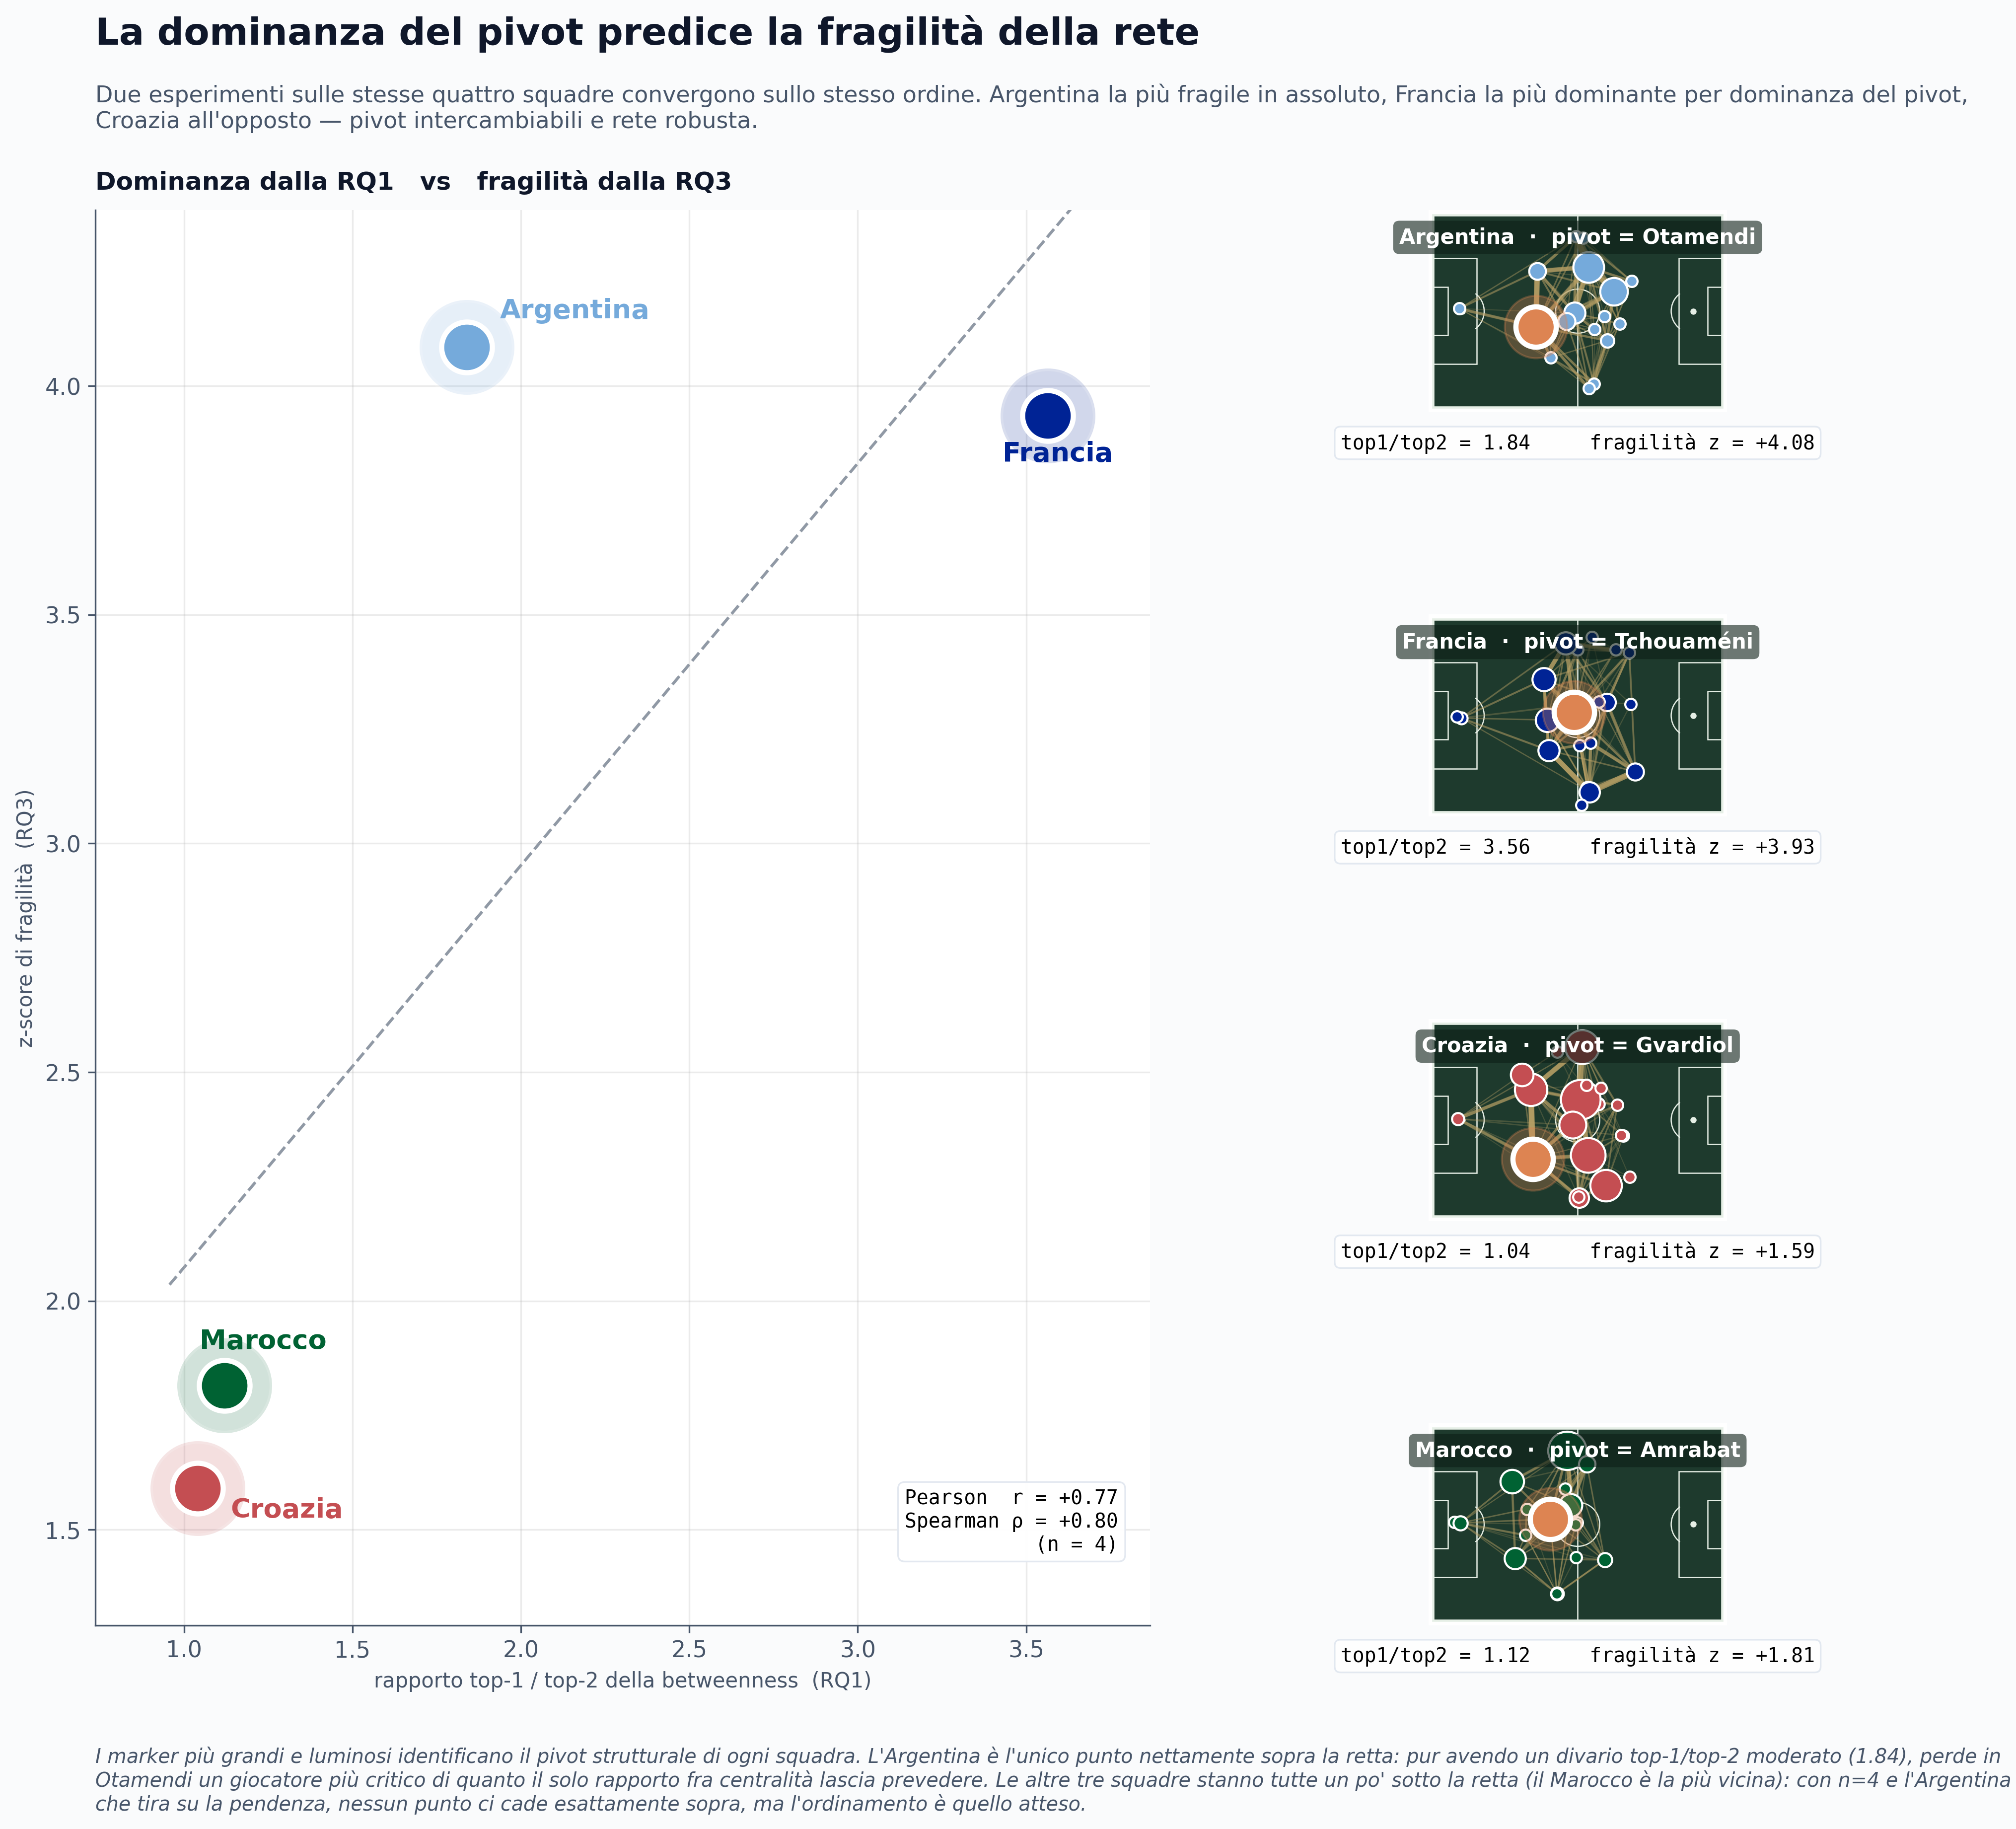

In [10]:
# Flagship composite: scatter + four pitch mini-cards on the side.

fig = plt.figure(figsize=FIG["flagship"], facecolor=BG)
gs = fig.add_gridspec(
    nrows=4, ncols=12,
    left=0.05, right=0.97, top=0.86, bottom=0.10,
    hspace=1.0, wspace=0.6,
)

# --- Banner -----------------------------------------------------------------
fig.text(0.05, 0.965,
         "La dominanza del pivot predice la fragilità della rete",
         ha="left", va="top", fontsize=TEXT["fig_title"] + 2,
         fontweight="semibold", color=INK)
fig.text(0.05, 0.928,
         "Due esperimenti sulle stesse quattro squadre convergono sullo stesso ordine. "
         "Argentina la più fragile in assoluto, Francia la più dominante per dominanza "
         "del pivot, Croazia all'opposto — pivot intercambiabili e rete robusta.",
         ha="left", va="top", fontsize=TEXT["fig_subtitle"], color=INK_SOFT,
         wrap=True)

# --- Main panel: scatter ----------------------------------------------------
ax_main = fig.add_subplot(gs[0:4, 0:7])
# Best-fit line under data
slope, intercept = np.polyfit(joint["top1/top2"], joint["fragility z"], 1)
xs = np.linspace(joint["top1/top2"].min() * 0.92,
                 joint["top1/top2"].max() * 1.08, 50)
ax_main.plot(xs, slope * xs + intercept, "--", color=INK_SOFT, lw=1.4,
             alpha=0.6, zorder=1)
for team in TEAMS:
    x = joint.loc[team, "top1/top2"]
    y = joint.loc[team, "fragility z"]
    color = TEAM_COLORS[team]
    ax_main.scatter(x, y, s=2100, color=color, ec="white", lw=2.5,
                    alpha=0.18, zorder=2)
    ax_main.scatter(x, y, s=600, color=color, ec="white", lw=2.5, zorder=3)
    offsets = {"Argentina": (16, 14), "France": (-22, -22),
               "Croatia": (16, -14), "Morocco": (-12, 18)}
    ox, oy = offsets[team]
    team_it = {"Argentina":"Argentina","France":"Francia","Croatia":"Croazia","Morocco":"Marocco"}[team]
    ax_main.annotate(team_it, (x, y), xytext=(ox, oy), textcoords="offset points",
                     fontsize=13, fontweight="semibold", color=color)

# Correlation annotation in the corner
ax_main.text(0.97, 0.05,
             f"Pearson  r = {r:+.2f}\nSpearman ρ = {rs:+.2f}\n(n = 4)",
             transform=ax_main.transAxes, ha="right", va="bottom",
             fontsize=TEXT["annotation"], family="monospace",
             bbox=dict(boxstyle="round,pad=0.35", fc="white",
                       ec=MUTED, lw=0.8, alpha=0.96))

# Title for the panel
ax_main.set_title("Dominanza dalla RQ1   vs   fragilità dalla RQ3",
                  loc="left", pad=10,
                  fontsize=TEXT["panel_title"], fontweight="semibold", color=INK)
ax_main.set_xlabel("rapporto top-1 / top-2 della betweenness  (RQ1)",
                   fontsize=TEXT["annotation"] + 0.5, color=INK_SOFT)
ax_main.set_ylabel("z-score di fragilità  (RQ3)",
                   fontsize=TEXT["annotation"] + 0.5, color=INK_SOFT)
ax_main.grid(True, alpha=0.25)

_xlo, _xhi = joint["top1/top2"].min(), joint["top1/top2"].max()
_ylo, _yhi = joint["fragility z"].min(), joint["fragility z"].max()
_xpad = (_xhi - _xlo) * 0.12
_ypad = (_yhi - _ylo) * 0.12
ax_main.set_xlim(_xlo - _xpad, _xhi + _xpad)
ax_main.set_ylim(_ylo - _ypad, _yhi + _ypad)

# Side: four pitch mini-cards with the pivot 
for i, team in enumerate(TEAMS):
    ax = fig.add_subplot(gs[i, 7:])
    G = graphs[team]
    btw = weighted_betweenness(G)
    pivot = max(btw, key=btw.get)
    color = TEAM_COLORS[team]
    # Pitch
    draw_pitch(ax, color=PITCH_BG, line=PITCH_LN, lw=0.6)
    
    wmax = max(d["weight"] for _, _, d in G.edges(data=True))
    for u, v, d in G.edges(data=True):
        if d["weight"] < 6: continue
        if "x" not in G.nodes[u] or "x" not in G.nodes[v]: continue
        x1, y1 = G.nodes[u]["x"], G.nodes[u]["y"]
        x2, y2 = G.nodes[v]["x"], G.nodes[v]["y"]
        ax.plot([x1, x2], [y1, y2], color="#bba266",
                alpha=0.18 + 0.6*(d["weight"]/wmax),
                lw=0.35 + 2.5*(d["weight"]/wmax),
                zorder=2)
    # Nodes — pivot in orange
    btw_max = max(btw.values())
    for n in G.nodes():
        if "x" not in G.nodes[n]: continue
        x, y = G.nodes[n]["x"], G.nodes[n]["y"]
        size = 30 + 350 * btw.get(n, 0) / btw_max
        is_pivot = (n == pivot)
        node_color = ACCENT if is_pivot else color
        ec = "white"
        lw_e = 2.5 if is_pivot else 1.0
        zorder_n = 5 if is_pivot else 3
        # Glow under pivot
        if is_pivot:
            ax.scatter(x, y, s=size*2.4, color=ACCENT, alpha=0.30, zorder=4)
        ax.scatter(x, y, s=size, color=node_color, ec=ec, lw=lw_e,
                   zorder=zorder_n)
    team_it = {"Argentina":"Argentina","France":"Francia","Croatia":"Croazia","Morocco":"Marocco"}[team]
    ax.text(60, 75, f"{team_it}  ·  pivot = {short(pivot)}",
            ha="center", va="top",
            fontsize=TEXT["annotation"] + 0.5, color="white",
            fontweight="semibold",
            bbox=dict(boxstyle="round,pad=0.3", fc="#0d1f17", ec="none",
                      alpha=0.6))
    # Stats below
    z_score = float(fragility.loc[team, "fragility z"])
    dom_score = float(dom.loc[team, "top1/top2"])
    text_below_axes(
        ax,
        f"top1/top2 = {dom_score:.2f}     fragilità z = {z_score:+.2f}",
        y=-0.10, mono=True, box=True,
    )
fig.text(0.05, 0.035,
         "I marker più grandi e luminosi identificano il pivot strutturale di ogni squadra. "
         "L'Argentina è l'unico punto nettamente sopra la retta: pur avendo un divario top-1/top-2 "
         "moderato (1.84), perde in Otamendi un giocatore più critico di quanto il solo rapporto "
         "fra centralità lascia prevedere. Le altre tre squadre stanno tutte un po' sotto la retta "
         "(il Marocco è la più vicina): con n=4 e l'Argentina che tira su la pendenza, nessun punto "
         "ci cade esattamente sopra, ma l'ordinamento è quello atteso.",
         ha="left", va="top", fontsize=TEXT["annotation"], color=INK_SOFT,
         style="italic", wrap=True)

plt.show()


**Cosa abbiamo imparato.**

- **Pearson $r = +0.77$, Spearman $\rho = +0.80$**. Due esperimenti indipendenti su quattro squadre danno lo stesso ordinamento di fragilità: **Argentina ▸ Francia ▸ Marocco ▸ Croazia**. I due metodi sono allineati: il coherence check è superato.
- Per *magnitudo*, la **Francia** (Tchouaméni) è il caso da manuale — pivot estremamente dominante (top-1/top-2 = 3.56) e rete molto fragile ($z \approx 3.9$): quanto più è dominante, tanto più è fragile. La **Croazia** sta agli antipodi (top-1/top-2 = 1.04, $z \approx 1.6$) — pivot intercambiabili, rete robusta. Il **Marocco** è vicino alla Croazia, e ha senso: Hakimi e Amrabat hanno una betweenness quasi identica.
- Un'avvertenza sulla retta: con $n = 4$ e l'**Argentina** come outlier alto, la regressione ai minimi quadrati viene tirata verso l'alto. L'Argentina è l'unico punto **sopra** la retta; Francia, Croazia e Marocco ci stanno tutte un po' **sotto** (il Marocco è la più vicina). Non è quindi che tre punti cadano *esattamente* sulla linea — è che l'Argentina se ne discosta molto più delle altre, ed è proprio questo a renderla interessante.
- Perché l'**Argentina** è sopra la retta? Ha uno z-score di fragilità ($\approx 4.1$) più alto di quanto il rapporto top-1 / top-2 (1.84) lascerebbe prevedere. Il motivo si vede guardando la classifica intera della betweenness: Otamendi *in assoluto* ha una betweenness pesata vicinissima a quella di Tchouaméni (0.548 vs 0.526) — è quasi altrettanto dominante per flusso che gli passa attraverso — ma il suo divario col secondo (De Paul, 0.298) è meno marcato di quello fra Tchouaméni e il resto della Francia. Il rapporto top-1/top-2 cattura solo lo *stacco* dal secondo, non la *quota assoluta* di flusso del pivot, e per l'Argentina queste due cose divergono.
- Da un punto di vista narrativo, il fatto che l'Argentina (vincitrice del torneo) sia la squadra **più fragile** è un piccolo paradosso interessante: ha vinto un Mondiale non con la rete più resiliente, ma con quella che dipendeva di più da un singolo giocatore. Vale la pena ricordare però che il pivot strutturale (Otamendi, difensore centrale) non è necessariamente il *miglior giocatore* nel senso comune: è il giocatore attraverso cui passa più *flusso*, una proprietà della rete, non del talento individuale.


---
## In sintesi

- La **fragilità della rete dei passaggi** di una squadra si legge in larga parte dalla sua struttura: il divario fra top-1 e top-2 della weighted betweenness la predice bene (**$r = +0.77$, $\rho = +0.80$, $n = 4$**). I due esperimenti, RQ1 sulle centralità statiche e RQ3 sulle rimozioni dinamiche, danno la stessa lettura — è un risultato di consistenza interna importante per il progetto, perché significa che le storie raccontate nei due notebook non si contraddicono fra loro.
- $S(q)$ della NS07 non si può applicare a queste reti perché sono troppo dense per spezzarsi togliendo un nodo solo. La nostra adattamento — due metriche di danno relativo, lunghezza media dei cammini ed efficienza globale, entrambe pesate con `1/peso` come distanza — cattura lo stesso tipo di danno della robustezza classica ma in un modo che funziona anche su reti piccole, dense e pesate. È un esempio concreto di *trasferire un'idea dalla NS07 a un dominio che esce dal range tipico della letteratura*, che è una delle cose interessanti che il corso chiede di saper fare.
- Il risultato di Albert, Jeong e Barabási sulle reti scale-free vale *qualitativamente* anche su questi piccoli grafi pesati del calcio: l'attacco mirato fa molto più danno della rimozione casuale, e la differenza è maggiore quando un hub è molto dominante. Il fatto che il risultato si trasferisca da reti con migliaia di nodi e topologia scale-free a reti con venti nodi e densità altissima è di per sé un piccolo argomento a favore della generalità del meccanismo: non sono le proprietà di scala specifiche della distribuzione del grado a renderlo vero, è la semplice presenza di *snodi sproporzionatamente caricati di flusso*.
- **Lettura tattica.** L'Argentina è la squadra la cui rete dei passaggi dipendeva di più da un singolo giocatore (Otamendi), seguita dalla Francia di Tchouaméni. I tre centrocampisti quasi intercambiabili della Croazia (Modrić, Brozović, Kovačić, più Gvardiol come quarto snodo dietro) erano l'opposto — un nucleo ridondante. L'Argentina ha vinto il torneo con una struttura più simile a quella francese che a quella croata, ed è una tensione interessante che la RQ1 già lasciava intravedere: la *vittoria* in un torneo non si predice dalla *robustezza* della rete, e probabilmente non dovrebbe nemmeno — la robustezza misura la capacità di resistere a rimozioni, non la qualità del gioco quando tutti i giocatori chiave sono in campo.